In [449]:

import os 
import sys
sys.path.append(os.path.dirname(os.getcwd()))

import yaml
import json
from pprint import pprint
from glob import glob
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import cv2
import xml.etree.ElementTree as ET
from svglib.svglib import svg2rlg
from reportlab.graphics import renderPM
import pyrender

import pygarment as pyg
import open3d as o3d
import trimesh
import plotly.graph_objects as go
import PIL
from PIL import Image

from analysis_utils import visualize_meshes_plotly, v_id_map, plot_panel_info

PROJECT_ROOT_PATH = "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/"
GARMENT_ROOT_PATH = os.path.join(PROJECT_ROOT_PATH, "GarmentCodeData_v2")
BODY_ROOT_PATH = os.path.join(PROJECT_ROOT_PATH, "body_mesh")
MEAN_ALL_BODY_PATH = os.path.join(PROJECT_ROOT_PATH, "neutral_body/mean_all.obj")
    
default_body_mesh = trimesh.load(MEAN_ALL_BODY_PATH)

print("body vertices", default_body_mesh.vertices.shape)
print("body faces", default_body_mesh.faces.shape)

body vertices (23751, 3)
body faces (47500, 3)


### Rendering Functions and Settings

In [451]:
# basic render utility functions

import os
import platform
if platform.system() == 'Linux':
    os.environ["PYOPENGL_PLATFORM"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"
os.environ['MESA_GL_VERSION_OVERRIDE'] = '4.1' 
os.environ['MESA_GLSL_VERSION_OVERRIDE'] = '410'

def rotate_matrix_y(matrix, angle_deg):
    rotation_angle = angle_deg * (np.pi / 180)

    # Define the rotation matrix for 180-degree rotation around the y-axis
    rotation_matrix = np.array([
        [np.cos(rotation_angle), 0, np.sin(rotation_angle), 0],
        [0, 1, 0, 0],
        [-np.sin(rotation_angle), 0, np.cos(rotation_angle), 0],
        [0, 0, 0, 1]
    ])

    # Apply the rotation to the mesh vertices
    rot_matrix = np.dot(rotation_matrix, matrix)
    return rot_matrix

def rotate_matrix_x(matrix, angle_deg):
    rotation_angle = angle_deg * (np.pi / 180)

    # Define the rotation matrix for 180-degree rotation around the y-axis
    rotation_matrix = np.array([
        [1, 0, 0, 0],
        [0, np.cos(rotation_angle), -np.sin(rotation_angle), 0],
        [0, np.sin(rotation_angle), np.cos(rotation_angle), 0],
        [0, 0, 0, 1]
    ])

    # Apply the rotation to the mesh vertices
    rot_matrix = np.dot(rotation_matrix, matrix)
    return rot_matrix

def create_lights(scene, intensity=30.0):
    light_positions = [
        np.array([1.60614, 1.5341, 1.23701]),
        np.array([1.31844, 1.92831, -2.52238]),
        np.array([-2.80522, 1.2594, 2.34624]),
        np.array([0.160261, 1.81789, 3.52215]),
        np.array([-2.65752, 1.41194, -1.26328])
    ]
    light_colors = [
        [1.0, 1.0, 1.0],
        [1.0, 1.0, 1.0],
        [1.0, 1.0, 1.0],
        [1.0, 1.0, 1.0],
        [1.0, 1.0, 1.0]
    ]

    # Add lights to the scene
    for i in range(5):
        light = pyrender.PointLight(color=light_colors[i], intensity=intensity)
        light_pose = np.eye(4)
        light_pose[:3, 3] = light_positions[i]
        scene.add(light, pose=light_pose)



def create_camera(pyrender, pyrender_body_mesh, scene, side, camera_location=None):

    # Create a camera
    y_fov = np.pi / 6. 
    camera = pyrender.PerspectiveCamera(yfov=y_fov)
    

    if camera_location is None:
        # Evaluate w.r.t. body

        fov = 50  # Set your desired field of view in degrees 

        # # Calculate the bounding box center of the mesh
        bounding_box_center = pyrender_body_mesh.bounds.mean(axis=0)

        # Calculate the diagonal length of the bounding box
        diagonal_length = np.linalg.norm(pyrender_body_mesh.bounds[1] - pyrender_body_mesh.bounds[0])

        # Calculate the distance of the camera from the object based on the diagonal length
        distance = 1.5 * diagonal_length / (2 * np.tan(np.radians(fov / 2)))

        camera_location = bounding_box_center
        camera_location[-1] += distance

    # Calculate the camera pose
    camera_pose = np.array([
        [1.0, 0.0, 0.0, camera_location[0]],
        [0.0, 1.0, 0.0, camera_location[1]],
        [0.0, 0.0, 1.0, camera_location[2]],
        [0.0, 0.0, 0.0, 1.0]
    ])

    camera_pose = rotate_matrix_x(camera_pose, -15)
    camera_pose = rotate_matrix_y(camera_pose, 20)
    if side == 'back':
        camera_pose = rotate_matrix_y(camera_pose, 180)
    elif side == 'right':
        camera_pose = rotate_matrix_y(camera_pose, -90)
    elif side == 'left':
        camera_pose = rotate_matrix_y(camera_pose, 90)

    # Set camera's pose in the scene
    scene.add(camera, pose=camera_pose)
    
render_props = {
    "resolution": [800, 800],
    "sides": ["front", "back", "right", "left"],
    "front_camera_location": [0, 0.97, 4.15],
    "uv_texture": {
        "seam_width": 0.5,
        "dpi": 1500,
        "fabric_grain_texture_path": "./assets/img/fabric_texture.png",
        "fabric_grain_resolution": 5
    }
}


## Visualize Default Body Setting

## Note

garment_5000_27/random_body/dataset_properties_random_body.yaml 도 고려해야 함

In [452]:
IDX = 1000
# BODY_TYPE = "random_body"
BODY_TYPE = "default_body"

garment_path = sorted(list(filter(
    os.path.isdir,
    glob(os.path.join(GARMENT_ROOT_PATH, "*", BODY_TYPE, "*"))
)))[IDX]

# garment_path = "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_0/default_body/rand_0BD28UCVO8"
# garment_path = "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_0/default_body/rand_0AAY3NQH8J"
# garment_path = "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_3/default_body/rand_005ZYVMOCL"
garment_path = "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_0/default_body/rand_0A36YXPNV0"
garment_id = os.path.basename(garment_path)

SPEC_FILE_PATH = os.path.join(garment_path, f"{garment_id}_specification.json")

pattern = pyg.pattern.wrappers.VisPattern(SPEC_FILE_PATH)

panel_svg_path_dict = {
    panel_name : pattern._draw_a_panel(
        panel_name, apply_transform=False, fill=True
    )
    for panel_name in pattern.panel_order()
}
stitch_dict = {
    i : v for i, v in enumerate(pattern.pattern['stitches'])
}

print(stitch_dict)

{0: [{'panel': 'sl_right_cuff_skirt_f', 'edge': 3}, {'panel': 'sl_right_cuff_skirt_b', 'edge': 0}], 1: [{'panel': 'sl_right_cuff_skirt_f', 'edge': 1}, {'panel': 'sl_right_cuff_skirt_b', 'edge': 2}], 2: [{'panel': 'right_sleeve_f', 'edge': 3}, {'panel': 'right_sleeve_b', 'edge': 1}], 3: [{'panel': 'right_sleeve_f', 'edge': 4}, {'panel': 'right_sleeve_b', 'edge': 0}], 4: [{'panel': 'right_sleeve_f', 'edge': 1}, {'panel': 'right_sleeve_b', 'edge': 4}], 5: [{'panel': 'sl_right_cuff_skirt_f', 'edge': 2}, {'panel': 'right_sleeve_f', 'edge': 0}], 6: [{'panel': 'sl_right_cuff_skirt_b', 'edge': 1}, {'panel': 'right_sleeve_b', 'edge': 5}], 7: [{'panel': 'right_sleeve_f', 'edge': 2}, {'panel': 'right_ftorso', 'edge': 5}], 8: [{'panel': 'right_sleeve_b', 'edge': 2}, {'panel': 'right_ftorso', 'edge': 4}], 9: [{'panel': 'right_sleeve_b', 'edge': 3}, {'panel': 'right_btorso', 'edge': 4}], 10: [{'panel': 'right_ftorso', 'edge': 3}, {'panel': 'right_btorso', 'edge': 5}], 11: [{'panel': 'right_ftorso', 

In [453]:
# with open(os.path.join(
#     "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_3/default_body/rand_005ZYVMOCL",
#     "rand_005ZYVMOCL_specification.json"
# ), "r") as f:
#     spec = json.load(f)
    
# pprint(spec["pattern"]["stitches"])

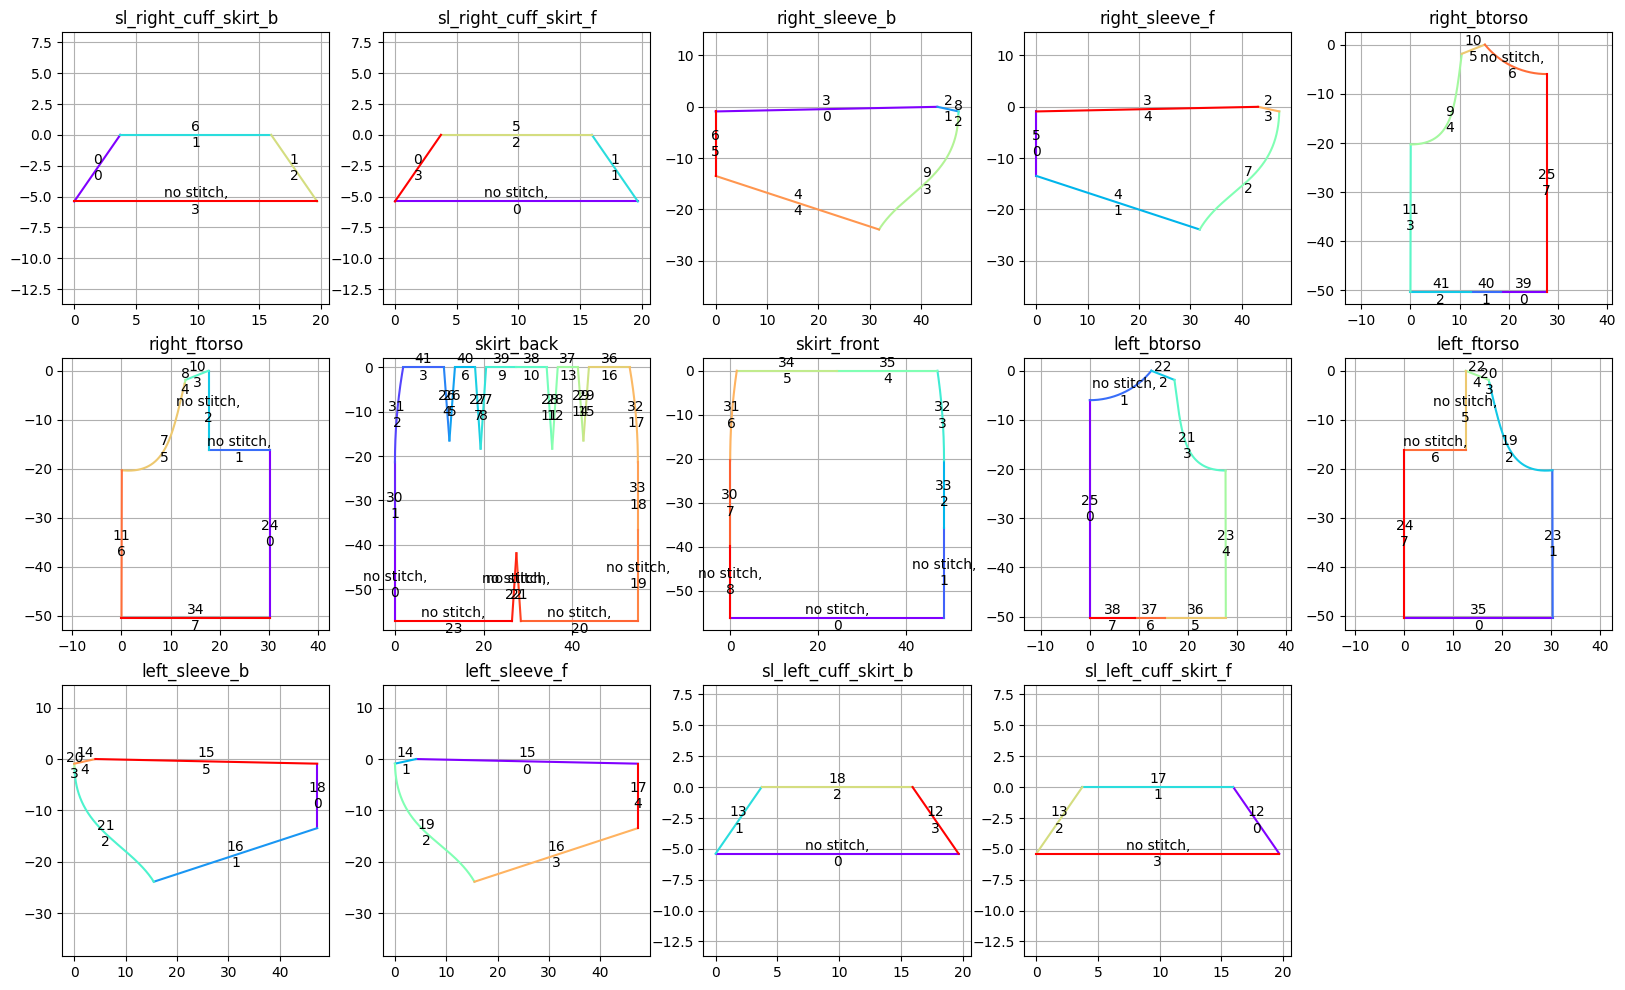

In [454]:
FIGLEN = 4
NCOLS = int(np.sqrt(len(panel_svg_path_dict)))
NROWS = int(np.ceil(len(panel_svg_path_dict) / NCOLS))
NCOLS = 5
NROWS = 3

plt.figure(figsize=(FIGLEN * NCOLS, FIGLEN * NROWS))
for i, (panel_name, panel) in enumerate(panel_svg_path_dict.items()):
    ax = plt.subplot(NROWS, NCOLS, i + 1)
    ax.set_title(panel_name)
    plot_panel_info(
        ax, panel_name, panel_svg_path_dict, stitch_dict,
        N_SAMPLES=1000
    )
# plt.savefig(f"{garment_id}_panel_vis.png")
plt.show()

In [455]:
def get_vertex_neighbors(faces, vertex_mask):
    """Get 1-hop neighbor vertices of masked vertices"""
    neighbor_mask = np.zeros(len(vertex_mask), dtype=bool)
    
    face_mask = np.any(vertex_mask[faces], axis=1)
    relevant_faces = faces[face_mask]
    
    neighbor_mask[relevant_faces.flatten()] = True
    
    return neighbor_mask

simulated_garment_mesh = trimesh.load_mesh(
    os.path.join(garment_path, f"{garment_id}_sim.ply"),
    process=False
)
simulated_garment_mesh.vertices = simulated_garment_mesh.vertices / 100

tex_image = PIL.Image.open(os.path.join(garment_path, f"{garment_id}_texture.png"))
texture = trimesh.visual.TextureVisuals(
    simulated_garment_mesh.visual.uv,
    image=tex_image
)
simulated_garment_mesh.visual = texture

print("vertices", simulated_garment_mesh.vertices.shape)
print("faces", simulated_garment_mesh.faces.shape)

idx_convert_map = v_id_map(simulated_garment_mesh.vertices)

print("idx_convert_map length", len(idx_convert_map))
print()

# Read Vertex Label
with open(os.path.join(garment_path, f"{garment_id}_sim_segmentation.txt"), "r") as f:
    segmentation = list(map(
        lambda x : x.strip(),
        f.readlines()
    ))

panel_vertex_mask_dict = {}
for k in panel_svg_path_dict.keys():
    raw_mask = list(map(
        lambda x : True if x.startswith(k) else False,
        segmentation
    ))
    panel_vertex_mask_dict[k] = np.array(list(map(
        lambda idx : True if raw_mask[idx] else False,
        idx_convert_map
    )))

stitch_vertex_mask_dict = {}
stitch_vertex_extended_mask_dict = {}
for k in stitch_dict.keys():
    raw_mask = list(map(
        lambda x : True if f"stitch_{k}" in x.split(",") else False,
        segmentation
    ))
    base_mask = np.array(list(map(
        lambda idx : True if raw_mask[idx] else False,
        idx_convert_map
    )))
    stitch_vertex_mask_dict[k] = base_mask
    stitch_vertex_extended_mask_dict[k] = get_vertex_neighbors(simulated_garment_mesh.faces, base_mask)
    
pprint(list(panel_vertex_mask_dict.keys()))
print(list(stitch_vertex_mask_dict.keys()))


vertices (18002, 3)
faces (34015, 3)
idx_convert_map length 18002

['sl_right_cuff_skirt_b',
 'sl_right_cuff_skirt_f',
 'right_sleeve_b',
 'right_sleeve_f',
 'right_btorso',
 'right_ftorso',
 'skirt_back',
 'skirt_front',
 'left_btorso',
 'left_ftorso',
 'left_sleeve_b',
 'left_sleeve_f',
 'sl_left_cuff_skirt_b',
 'sl_left_cuff_skirt_f']
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]


In [456]:
# # Make Filtered Mesh

# full_vertices = np.array(simulated_garment_mesh.vertices)
# full_edges = np.array(simulated_garment_mesh.edges)
# full_faces = np.array(simulated_garment_mesh.faces)

# filtered2full_idx_map = {}
# for idx, filtered_idx in enumerate(idx_convert_map):
#     if filtered_idx in filtered2full_idx_map :
#         filtered2full_idx_map[filtered_idx].append(idx)
#     else:
#         filtered2full_idx_map[filtered_idx] = [idx]
        
        
# filtered_idx_list = []
# filtered_vertices = []
# for full_idx, filtered_idx in enumerate(idx_convert_map):
#     if filtered_idx in filtered_idx_list:
#         continue
#     filtered_idx_list.append(filtered_idx)
#     filtered_vertices.append(full_vertices[full_idx])
# filtered_vertices = np.array(filtered_vertices)


# filtered_edges = []
# for orig_edge in full_edges:
#     stt = idx_convert_map[orig_edge[0]]
#     end = idx_convert_map[orig_edge[1]]
#     filtered_edges.append([stt, end])
# filtered_edges = np.array(filtered_edges)

# filtered_faces = []
# for idx, orig_face in enumerate(full_faces):
    
#     v1, v2, v3 = sorted([
#         idx_convert_map[orig_face[0]],
#         idx_convert_map[orig_face[1]],
#         idx_convert_map[orig_face[2]]
#     ])
#     filtered_faces.append([v1, v2, v3])
# filtered_faces = np.array(filtered_faces)


# filtered_mesh = trimesh.Trimesh(
#     vertices=filtered_vertices,
#     edges=filtered_edges,
#     faces=filtered_faces,
#     process=False
# )


# filtered_stitch_vertex_mask_dict = {}
# for stitch_idx in stitch_vertex_mask_dict.keys():
#     filtered_stitch_vertex_mask_dict[stitch_idx] = np.array(
#         [False] * len(filtered_vertices)
#     )
#     for orig_vert_idx, val in enumerate(stitch_vertex_mask_dict[stitch_idx]):
#         if val:
#             filtered_vert_idx = idx_convert_map[orig_vert_idx]
#             filtered_stitch_vertex_mask_dict[stitch_idx][filtered_vert_idx] = True


# # STITCH_IDX = 0
# # visualize_meshes_plotly(
# #     [filtered_mesh,],
# #     vertices_list=[
# #         filtered_mesh.vertices[filtered_stitch_vertex_mask_dict[STITCH_IDX]]
# #     ],
# #     vertices_color_list=["red"],
# #     vertex_marker_size=5
# # )


In [524]:
import random

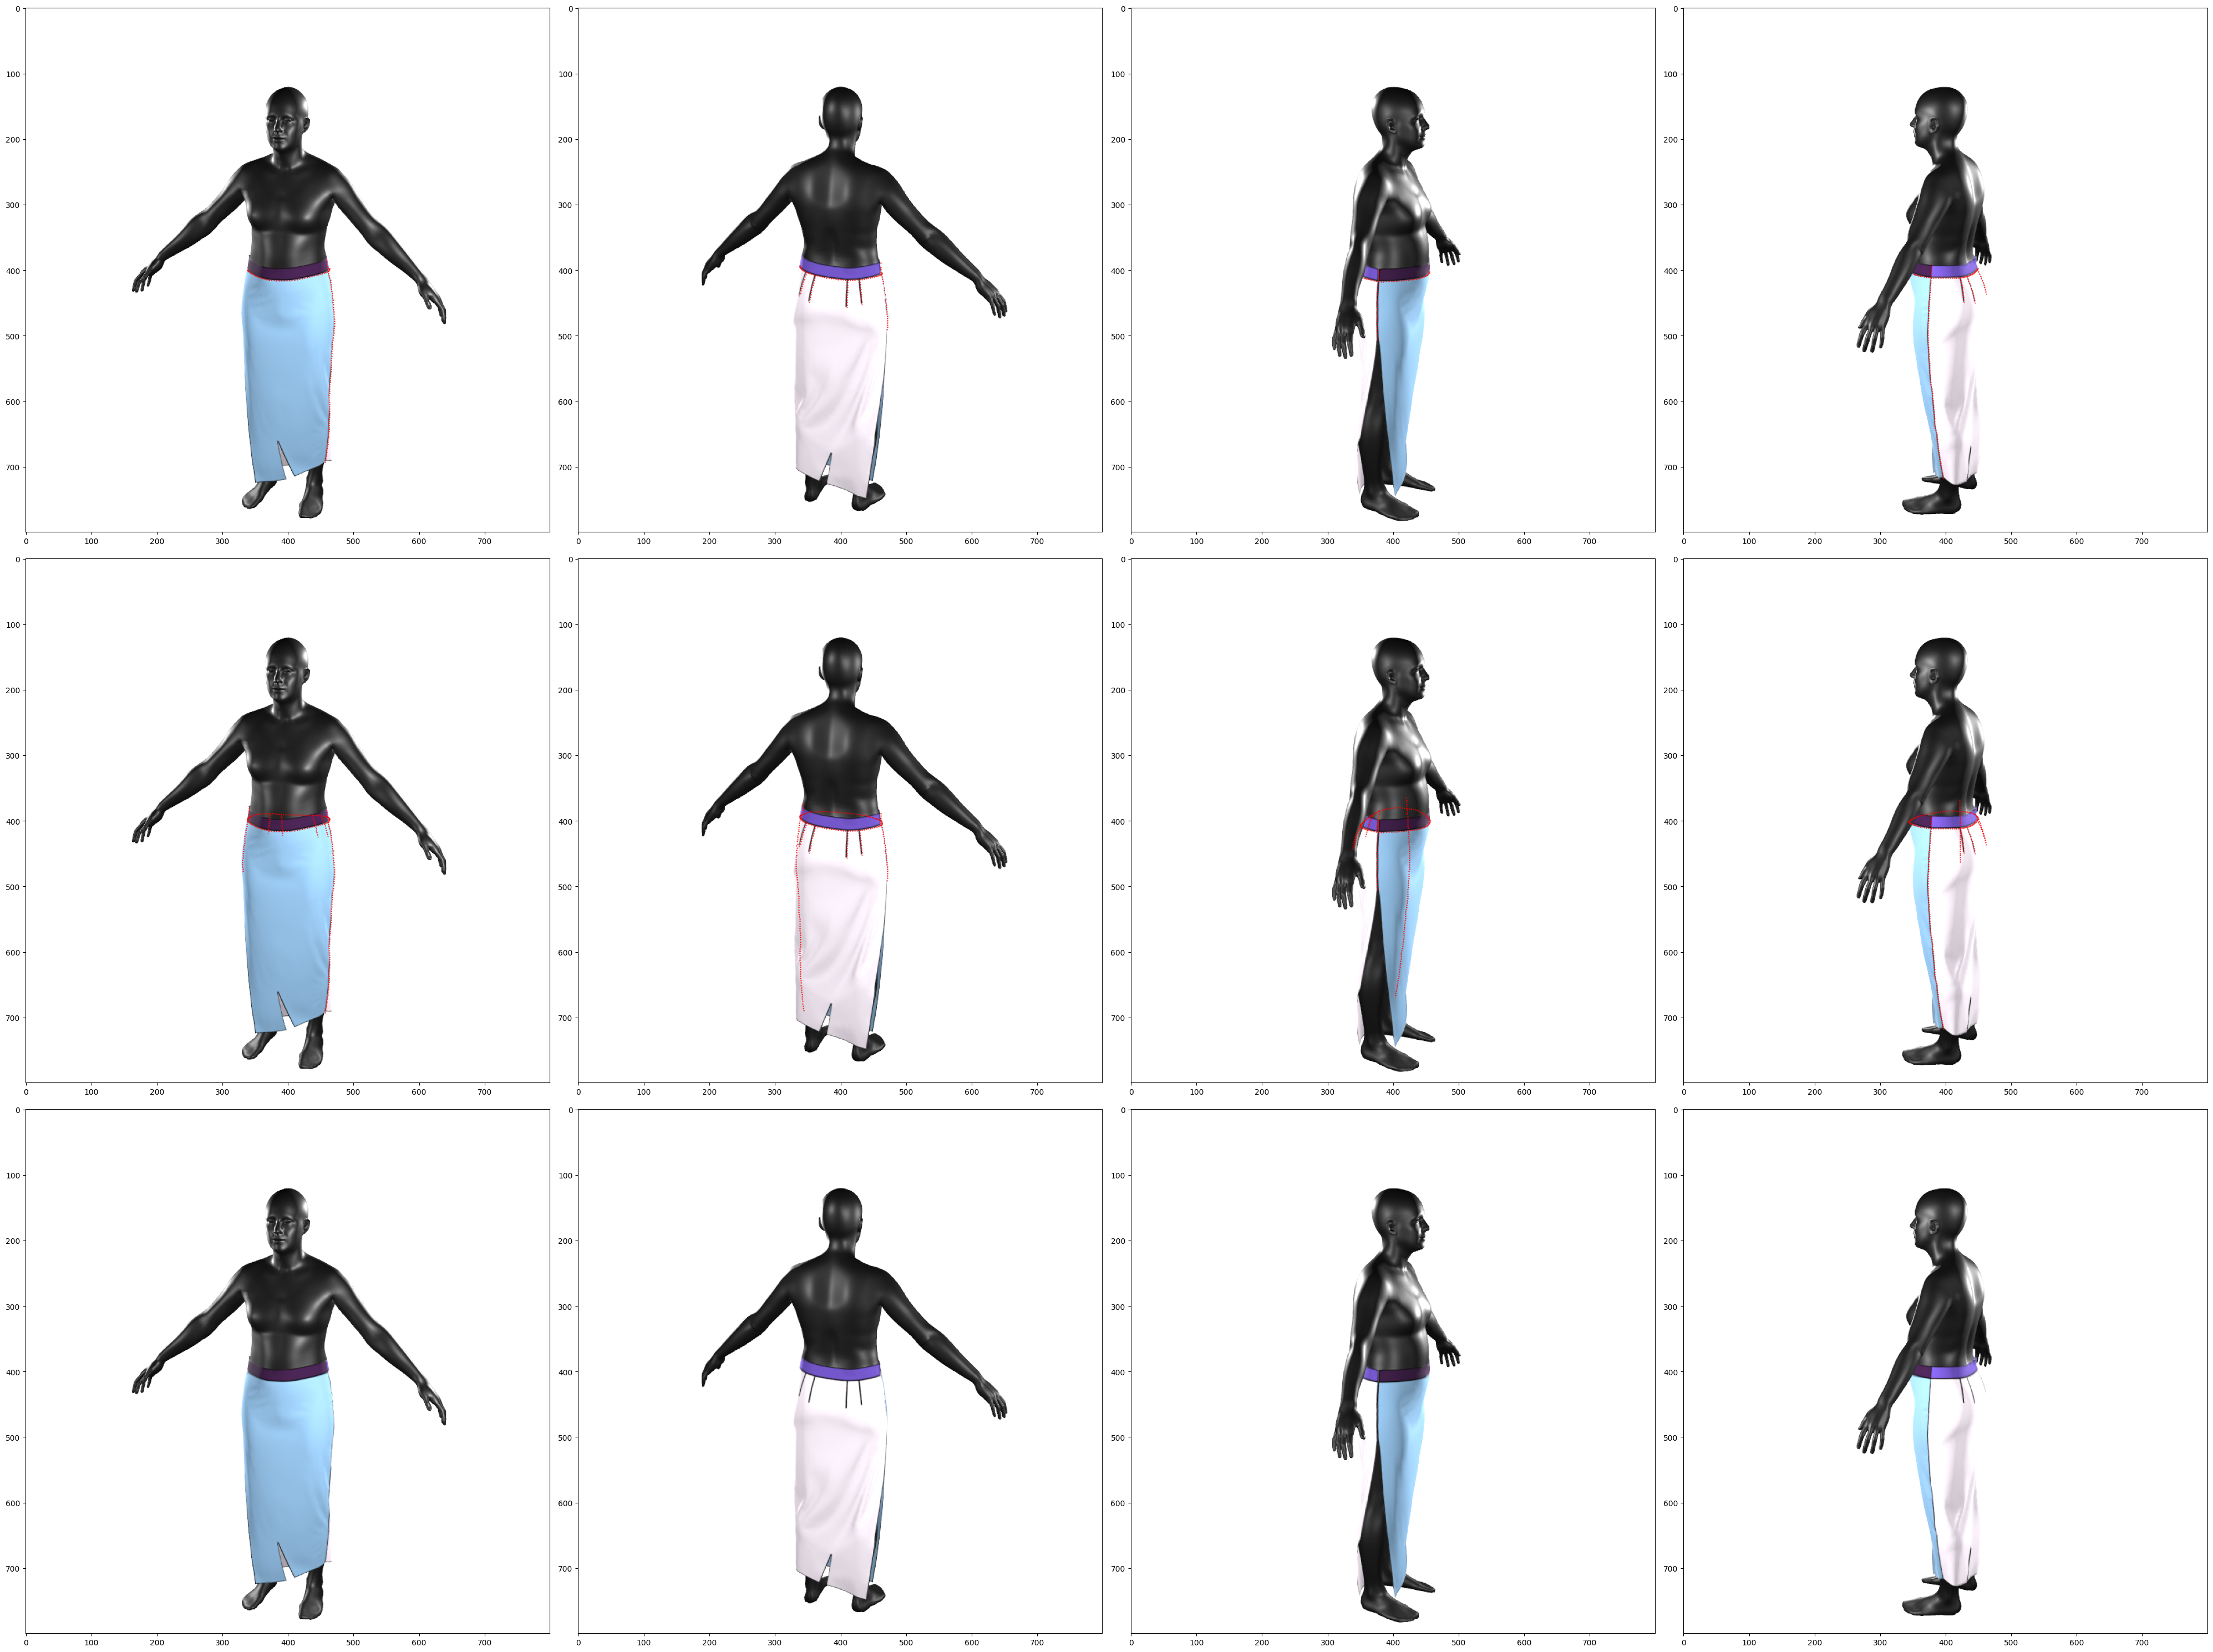

In [546]:


# BODY_TYPE = "random_body"
BODY_TYPE = "default_body"

garment_path_list = sorted(list(filter(
    os.path.isdir,
    glob(os.path.join(GARMENT_ROOT_PATH, "*", BODY_TYPE, "*"))
)))


# garment_path = "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_3/default_body/rand_005ZYVMOCL"
# garment_path = "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_0/default_body/rand_0AAY3NQH8J"
# garment_path = "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_0/default_body/rand_0BD28UCVO8"
# garment_path = "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_0/default_body/rand_0A36YXPNV0"
# ================================
IDX = 1000

IDX = random.randint(0, len(garment_path_list) - 1)
# ================================

garment_path = garment_path_list[IDX]

garment_id = os.path.basename(garment_path)

SPEC_FILE_PATH = os.path.join(garment_path, f"{garment_id}_specification.json")

pattern = pyg.pattern.wrappers.VisPattern(SPEC_FILE_PATH)

panel_svg_path_dict = {
    panel_name : pattern._draw_a_panel(
        panel_name, apply_transform=False, fill=True
    )
    for panel_name in pattern.panel_order()
}
stitch_dict = {
    i : v for i, v in enumerate(pattern.pattern['stitches'])
}


simulated_garment_mesh = trimesh.load_mesh(
    os.path.join(garment_path, f"{garment_id}_sim.ply"),
    process=False
)
simulated_garment_mesh.vertices = simulated_garment_mesh.vertices / 100

tex_image = PIL.Image.open(os.path.join(garment_path, f"{garment_id}_texture.png"))
texture = trimesh.visual.TextureVisuals(
    simulated_garment_mesh.visual.uv,
    image=tex_image
)
simulated_garment_mesh.visual = texture

idx_convert_map = v_id_map(simulated_garment_mesh.vertices)

# Read Vertex Label
with open(os.path.join(garment_path, f"{garment_id}_sim_segmentation.txt"), "r") as f:
    segmentation = list(map(
        lambda x : x.strip(),
        f.readlines()
    ))

panel_vertex_mask_dict = {}
for k in panel_svg_path_dict.keys():
    raw_mask = list(map(
        lambda x : True if x.startswith(k) else False,
        segmentation
    ))
    panel_vertex_mask_dict[k] = np.array(list(map(
        lambda idx : True if raw_mask[idx] else False,
        idx_convert_map
    )))

stitch_vertex_mask_dict = {}
for k in stitch_dict.keys():
    raw_mask = list(map(
        lambda x : True if f"stitch_{k}" in x.split(",") else False,
        segmentation
    ))
    base_mask = np.array(list(map(
        lambda idx : True if raw_mask[idx] else False,
        idx_convert_map
    )))
    stitch_vertex_mask_dict[k] = base_mask

# ready pyrender meshes
body_material = pyrender.MetallicRoughnessMaterial(
    baseColorFactor=(0.0, 0.0, 0.0, 1.0),  # RGB color, Alpha
    metallicFactor=0.658,  # Range: [0.0, 1.0]
    roughnessFactor=0.5  # Range: [0.0, 1.0]
)
pyrender_body_mesh = pyrender.Mesh.from_trimesh(default_body_mesh, material=body_material)


material = simulated_garment_mesh.visual.material.to_pbr()
material.baseColorFactor = [1., 1., 1., 1.]
material.doubleSided = True  # color both face sides  

white_back = Image.new('RGBA', material.baseColorTexture.size, color=(255, 255, 255, 255))
white_back.paste(material.baseColorTexture)
material.baseColorTexture = white_back.convert('RGB')  

simulated_garment_mesh.visual.material = material

pyrender_garm_mesh = pyrender.Mesh.from_trimesh(
    simulated_garment_mesh, smooth=True
) 



rendered_image_dict = {}
depth_image_dict = {}
projected_vertex_pose_dict = {}
vertex_visibility_mask_dict = {}

for side in render_props["sides"]:
    scene = pyrender.Scene(bg_color=(1., 1., 1., 0.))
    
    scene.add(pyrender_garm_mesh)
    scene.add(pyrender_body_mesh)

    create_camera(
        pyrender,
        pyrender_body_mesh, scene, side,
        camera_location=render_props["front_camera_location"]
    )
    create_lights(scene, intensity=80.)
    
    camera_node = list(filter(
        lambda x : x.camera is not None,
        scene.get_nodes()
    ))[-1]
    
    renderer = pyrender.OffscreenRenderer(
        viewport_width=render_props["resolution"][0],
        viewport_height=render_props["resolution"][1]
    )
    
    flags = pyrender.RenderFlags.RGBA | pyrender.RenderFlags.SKIP_CULL_FACES
    color, depth = renderer.render(scene, flags=flags)
    
    rendered_image_dict[side] = Image.fromarray(color)
    depth_image_dict[side] = depth
    
    view_matrix = np.linalg.inv(scene.get_pose(camera_node))
    proj_matrix = camera_node.camera.get_projection_matrix(*render_props["resolution"])
    
    vertices_homog = np.hstack([simulated_garment_mesh.vertices, np.ones((simulated_garment_mesh.vertices.shape[0], 1))])
    
    view_proj = proj_matrix @ view_matrix
    projected = vertices_homog @ view_proj.T
    
    z_coords = projected[:, 2].copy()
    projected = projected[:, :3] / projected[:, 3:4]
    
    pixel_coords = np.zeros((projected.shape[0], 2))
    pixel_coords[:, 0] = (projected[:, 0] + 1.0) * render_props["resolution"][0] / 2.0
    pixel_coords[:, 1] = render_props["resolution"][1] - (projected[:, 1] + 1.0) * render_props["resolution"][1] / 2.0
    
    px = np.clip(pixel_coords[:, 0].astype(int), 0, render_props["resolution"][0] - 1)
    py = np.clip(pixel_coords[:, 1].astype(int), 0, render_props["resolution"][1] - 1)
    
    THRESHOLD = 0.09
    visibility_mask = (z_coords > 0) & \
                (pixel_coords[:, 0] >= 0) & (pixel_coords[:, 0] < render_props["resolution"][0]) & \
                (pixel_coords[:, 1] >= 0) & (pixel_coords[:, 1] < render_props["resolution"][1]) & \
                (z_coords + THRESHOLD < depth[py, px])
                # (depth[py, px] - THRESHOLD < z_coords) & (depth[py, px] + THRESHOLD > z_coords)
    
    projected_vertex_pose_dict[side] = pixel_coords.tolist()
    vertex_visibility_mask_dict[side] = visibility_mask.tolist()
    
    renderer.delete()


# for side, depth_image in depth_image_dict.items():
#     np.save(os.path.join(garment_path, f"{garment_id}_depth_{side}.npy"), depth_image)
# with open(os.path.join(garment_path, f"{garment_id}_projected_vertex_pose.json"), "w") as f:
#     json.dump( projected_vertex_pose_dict, f)
# with open(os.path.join(garment_path, f"{garment_id}_vertex_visibility_mask.json"), "w") as f:
#     json.dump(vertex_visibility_mask_dict, f)


FIGLEN = 10
NROWS = 3
NCOLS = len(vertex_visibility_mask_dict.keys())
plt.figure(figsize=(FIGLEN * NCOLS, FIGLEN * NROWS))
for i, side in enumerate(vertex_visibility_mask_dict.keys()):
    plt.subplot(NROWS, NCOLS, i + 1)
    plt.imshow(rendered_image_dict[side])
    plt.tight_layout()
    vis_seam_pixel_coord = np.array(projected_vertex_pose_dict[side])[
        np.logical_and(
            np.array(list(stitch_vertex_mask_dict.values())).sum(axis=0).astype(bool),
            np.array(vertex_visibility_mask_dict[side])
        )
    ]
    plt.scatter(
        vis_seam_pixel_coord[:, 0],
        vis_seam_pixel_coord[:, 1],
        c="red",
        s=0.5, alpha=0.5
    )
    
    plt.subplot(NROWS, NCOLS, i + 1 + NCOLS)
    plt.imshow(rendered_image_dict[side])
    plt.tight_layout()
    
    seam_pixel_coord = np.array(projected_vertex_pose_dict[side])[
        np.array(list(stitch_vertex_mask_dict.values())).sum(axis=0).astype(bool)
    ]
    plt.scatter(
        seam_pixel_coord[:, 0],
        seam_pixel_coord[:, 1],
        c="red",
        s=0.5, alpha=0.5
    )
    
    plt.subplot(NROWS, NCOLS, i + 1 + NCOLS * 2)
    plt.imshow(rendered_image_dict[side])
    plt.tight_layout()

plt.show()


In [467]:
np.array(projected_vertex_pose_dict[side]).shape

(18002, 2)

In [471]:
np.array(projected_vertex_pose_dict[side])[vertex_visibility_mask_dict[side]].shape

(6785, 2)

In [469]:
np.array(vertex_visibility_mask_dict[side]).shape


(18002,)

In [465]:
# SIDE = "back"
# vertex_list = simulated_garment_mesh.vertices[vertex_visibility_mask_dict[SIDE]]
# print(vertex_list.shape)
# visualize_meshes_plotly(
#     simulated_garment_mesh,
#     vertices_list = [vertex_list],
#     vertices_color_list=["red"],
#     vertex_marker_size=2,
# )

In [459]:
vertex_visibility_mask_dict.keys()

dict_keys(['front', 'back', 'right', 'left'])

In [460]:
fltrd_vis_vert_mask_dict = {}
fltrd_proj_vert_pos_dict = {}

idx_convert_map_arr = np.array(idx_convert_map)
for side in vertex_visibility_mask_dict.keys():
    
    filtrd_idx_list = []
    
    fltrd_vis_mask = []
    fltrd_proj_vert_pos = []
    
    for orig_idx, fltrd_idx in enumerate(idx_convert_map_arr):
        if fltrd_idx in filtrd_idx_list:
            continue
        filtrd_idx_list.append(fltrd_idx)
        fltrd_vis_mask.append(vertex_visibility_mask_dict[side][orig_idx])
        fltrd_proj_vert_pos.append(projected_vertex_pose_dict[side][orig_idx])

    fltrd_vis_vert_mask_dict[side] = fltrd_vis_mask
    fltrd_proj_vert_pos_dict[side] = fltrd_proj_vert_pos
    
vis_sim_segment_pos_dict = {}
for side in fltrd_vis_vert_mask_dict.keys():
    for stch_idx in filtered_stitch_vertex_mask_dict.keys():
        fltrd_stch_mask = filtered_stitch_vertex_mask_dict[stch_idx]
        fltrd_vis_mask = fltrd_vis_vert_mask_dict[side]
        
        mask = fltrd_stch_mask & fltrd_vis_mask

In [461]:
# Find vertices that belong to seam line is easier done in filtered mesh
# first get idx of stitch vertices, and reorder them to construct a connected path

fltrd_seam_line_dict = {}
for fltrd_stch_idx in filtered_stitch_vertex_mask_dict.keys():
    fltrd_stch_vert_map = filtered_stitch_vertex_mask_dict[fltrd_stch_idx]
    fltrd_stch_vert_idx_arr = np.where(fltrd_stch_vert_map)[0]
    
    adj_dict = {}
    for v1, v2 in filtered_edges:
        if v1 in fltrd_stch_vert_idx_arr and v2 in fltrd_stch_vert_idx_arr:
            if v1 not in adj_dict: adj_dict[v1] = set()
            if v2 not in adj_dict: adj_dict[v2] = set()
            adj_dict[v1].add(v2)
            adj_dict[v2].add(v1)
    
    endpoints = [
        v for v in fltrd_stch_vert_idx_arr if len(adj_dict.get(v, set())) == 1
    ]
    if len(endpoints) != 2:
        
        print("stitch idx", fltrd_stch_idx)
        print(fltrd_stch_vert_idx_arr)
        print(f"Warning: Found {len(endpoints)} endpoints, expected 2. Path may not be linear.")
        continue
    
    seam_vert_idx_list = [endpoints[0]]
    while len(seam_vert_idx_list) < len(fltrd_stch_vert_idx_arr):
        current_vert = seam_vert_idx_list[-1]
        neighbors = adj_dict[current_vert]
        next_vert = next((v for v in neighbors if v not in seam_vert_idx_list), None)
        if next_vert is None:
            break
        seam_vert_idx_list.append(next_vert)
    fltrd_seam_line_dict[fltrd_stch_idx] = seam_vert_idx_list

stitch idx 8
[151]
stitch idx 20
[367]


In [462]:

MIN_CONSEC_VERT_TO_BE_SEGMENT = 2
# Connect Disconnected vertices, if length of disconnected vertices <= MIN_CONSEC_VERT_TO_DISCONNECT
MIN_CONSEC_VERT_TO_DISCONNECT = 2

fltrd_vis_seam_line_dict = {}
for side in fltrd_vis_vert_mask_dict.keys() :
    fltrd_vis_seam_line_dict[side] = {}
    vis_mask = np.array(fltrd_vis_vert_mask_dict[side])
    for stch_idx in fltrd_seam_line_dict.keys():
        
        fltrd_vis_seam_line_dict[side][stch_idx] = {}
        
        seam_vert_idx_list = fltrd_seam_line_dict[stch_idx]
        
        vis_list = []
        for seam_vert_idx in seam_vert_idx_list :
            vis_list.append(vis_mask[seam_vert_idx])
        fltrd_vis_seam_line_dict[side][stch_idx]["raw_idx_list"] = seam_vert_idx_list
        fltrd_vis_seam_line_dict[side][stch_idx]["raw_vis_mask"] = vis_list
        vis_list = np.array(vis_list)
        # If length of disconnection between visible seam vertices
        # is less then MIN_CONSEC_VERT_TO_DISCONNECT,
        # consider the disconnection is connected
        # (which change invisible seam vertices to visible)
        idx = 0
        while idx < len(vis_list) :
            if idx >= len(vis_list) - 2 :
                break
            while not (vis_list[idx] == True and vis_list[idx + 1] == False) :
                if idx >= len(vis_list) - 2 :
                    break
                idx += 1
            if idx >= len(vis_list) - 2 :
                break
            window_end_idx = min(idx + MIN_CONSEC_VERT_TO_DISCONNECT + 1, len(vis_list) - 1)
            for rid in range(window_end_idx, idx, -1) :
                if vis_list[rid] == True :
                    vis_list[idx:rid] = True
                    break
            idx = rid
            
            
        # If length of connection between visible seam vertices
        # is less then MIN_CONSEC_VERT_TO_BE_SEGMENT,
        # consider the connection is not a segment
        # (which change visible seam vertices to invisible)
        idx = 0
        while idx < len(vis_list) :
            if vis_list[idx] != True :
                idx += 1
                continue
            idx2 = idx + 1
            while idx2 < len(vis_list) and vis_list[idx2] == True :
                idx2 += 1
            if idx2 - idx < MIN_CONSEC_VERT_TO_BE_SEGMENT :
                vis_list[idx:idx2] = False
            idx = idx2
            
        line_segment_list = []
        if True in vis_list :
            idx = vis_list.tolist().index(True)
            while idx < len(vis_list) :
                line_segment = []
                while idx < len(vis_list) and vis_list[idx] == True :
                    line_segment.append(
                        seam_vert_idx_list[idx]
                    )
                    idx += 1
                if len(line_segment) > 0 :
                    line_segment_list.append(line_segment)
                idx += 1
        else :
            line_segment_list.append([])
            
        fltrd_vis_seam_line_dict[side][stch_idx]["segment_idx_list"] = line_segment_list


In [398]:
# SIDE = "front"
# stch_idx = 7

# visualize_meshes_plotly(
#     [filtered_mesh],
#     vertices_list = [
#         filtered_mesh.vertices[
#             fltrd_vis_seam_line_dict[SIDE][stch_idx]["segment_idx_list"][idx]
#         ]
#         for idx in range(len(fltrd_vis_seam_line_dict[SIDE][stch_idx]["segment_idx_list"]))
#     ],
#     vertices_color_list = ["red" for _ in range(len(fltrd_vis_seam_line_dict[SIDE][stch_idx]["segment_idx_list"]))],
#     vertex_marker_size = 5
# )

In [440]:
N_stitch, colors.shape

(41, (41, 4))

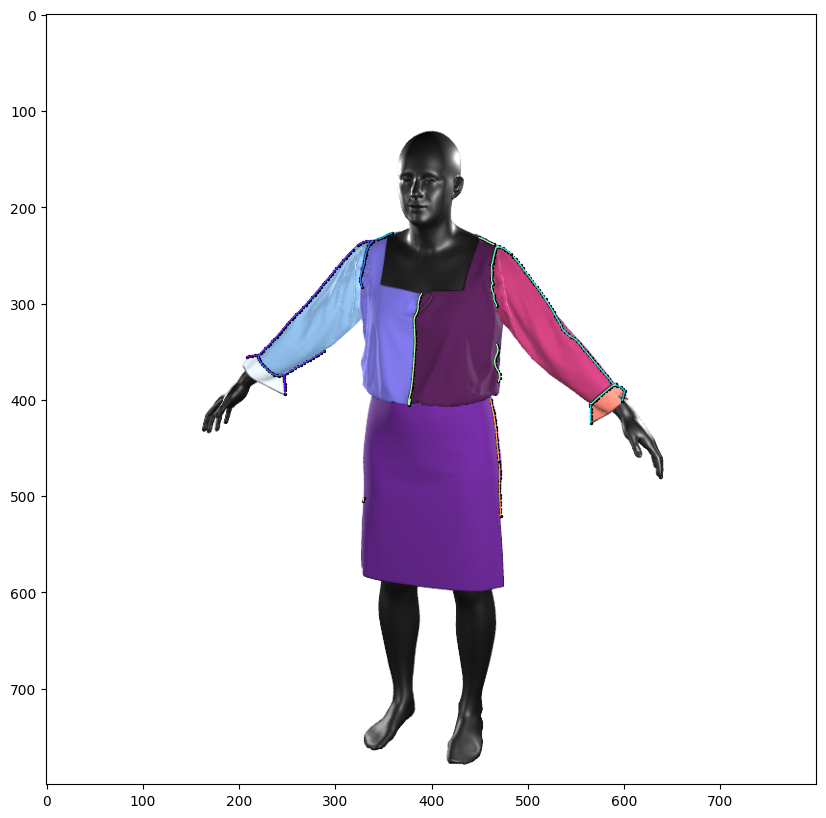

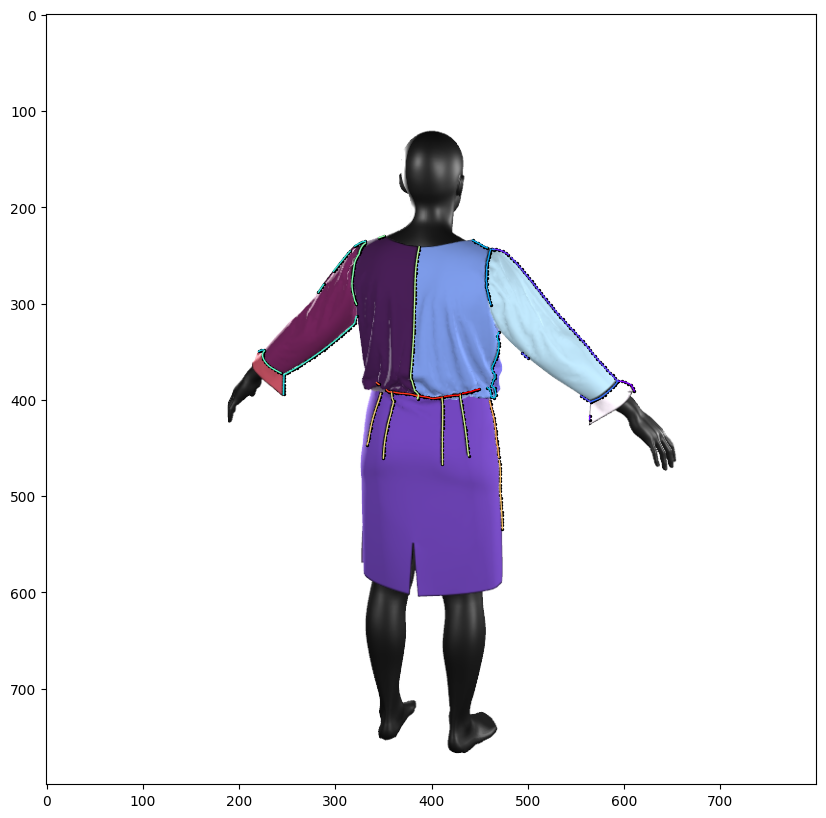

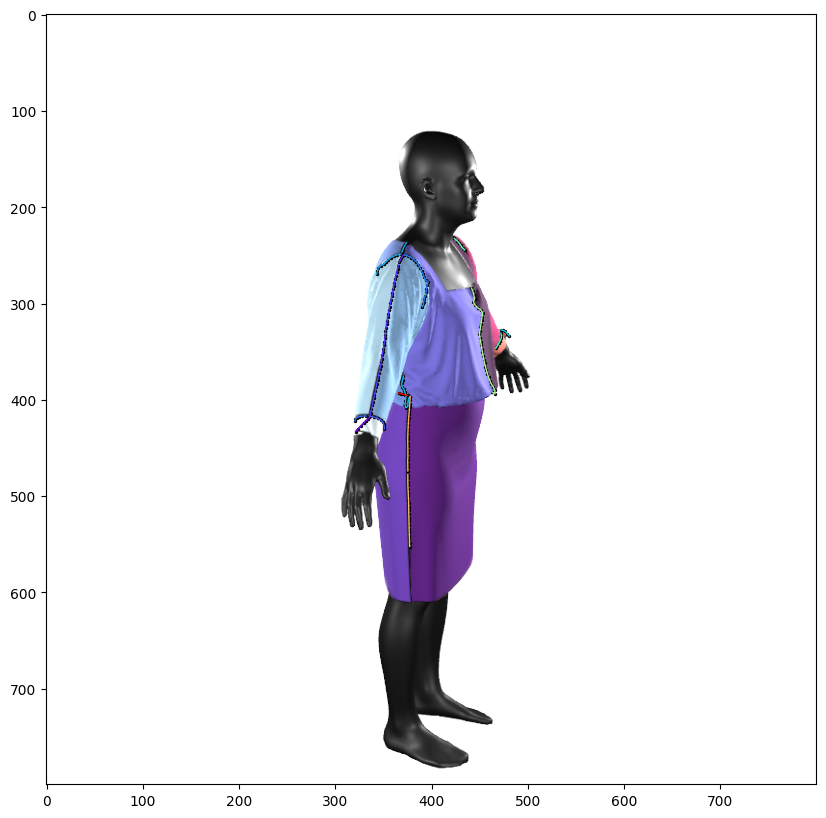

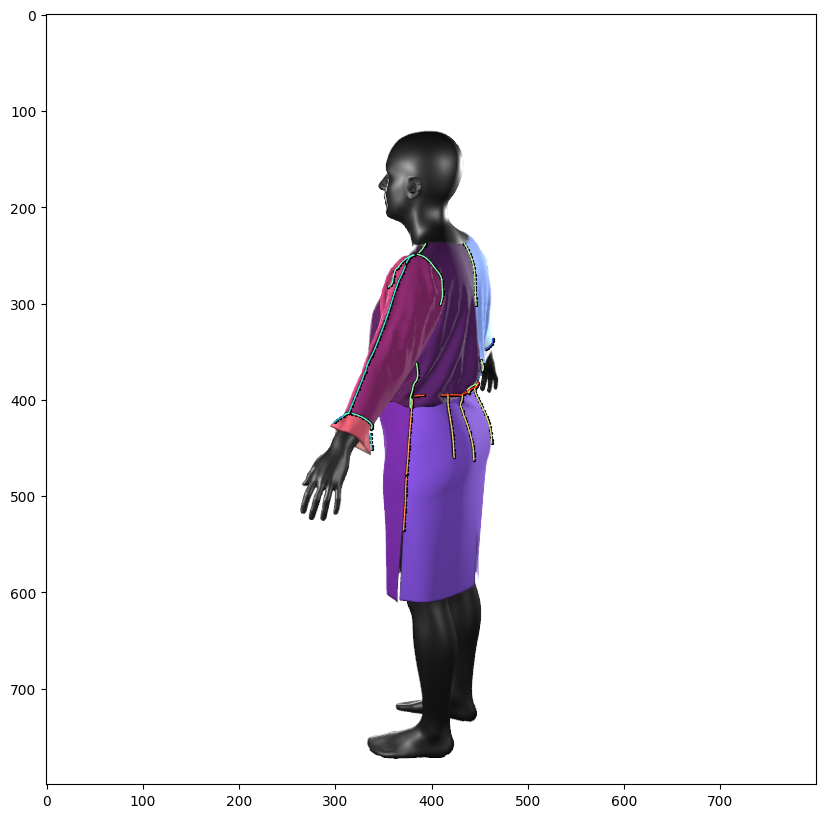

In [464]:
STCH_IDX_MAX = max(list(map(
    lambda stch_dict : max(stch_dict.keys()),
    fltrd_vis_seam_line_dict.values()
)))
colors = plt.cm.rainbow(np.linspace(0, 1, STCH_IDX_MAX + 1))

for side in fltrd_vis_seam_line_dict.keys():
    plt.figure(figsize=(10, 10))
    plt.imshow(rendered_image_dict[side])
    
    for seam_idx, seam_dict in fltrd_vis_seam_line_dict[side].items():
        for segment_idx, segment_idx_list in enumerate(seam_dict["segment_idx_list"]):
            
            x = [fltrd_proj_vert_pos_dict[side][idx][0] for idx in segment_idx_list]
            y = [fltrd_proj_vert_pos_dict[side][idx][1] for idx in segment_idx_list]
            
            # Draw polyline connecting the vertices
            plt.plot(x, y, '-', color=colors[seam_idx], linewidth=1)
            
            # Optionally add points at vertices
            plt.scatter(x, y, color="black", s=2)

    plt.show()

=====================================================================

In [350]:
# Test Code for connect and segment the seam line

import random

MIN_CONSEC_VERT_TO_BE_SEGMENT = 2

# Connect Disconnected vertices, if length of disconnected vertices <= MIN_CONSEC_VERT_TO_DISCONNECT
MIN_CONSEC_VERT_TO_DISCONNECT = 2

N = 20

data_arr = np.array(list(range(N)))
conn_arr = np.array([random.randint(0, 1) for _ in range(N)])
# ll = np.array(
#     [1, 1, 0, 1, 0, 1, 0, 0, 0, 1]
# )
conn_arr_b = conn_arr.copy()



print(
    "idx  :",
    "".join(map(
        lambda x : f"{x:3d}",
        data_arr.tolist()
    ))
)

print(
    "conn :",
    "".join(map(
        lambda x : f"{x:3d}",
        conn_arr.tolist()
    ))
)


## If length of disconnection < MIN_CONSEC_VERT_TO_DISCONNECT,
## then connect the disconnection
idx = 0
while idx < len(conn_arr) :
    if idx >= len(conn_arr) - 2 :
        break
    while not (conn_arr[idx] == 1 and conn_arr[idx + 1] == 0) :
        if idx >= len(conn_arr) - 2 :
            break
        idx += 1
    if idx >= len(conn_arr) - 2 :
        break
    window_end_idx = min(
        idx + MIN_CONSEC_VERT_TO_DISCONNECT + 1,
        len(conn_arr) - 1
    )
    # print(idx, window_end_idx, conn_arr[idx:window_end_idx+1].tolist())
    
    for rid in range(window_end_idx, idx, -1) :
        if conn_arr[rid] == 1 :
            conn_arr[idx:rid] = 1
            break
    
    idx = rid
    
    # print(conn_arr.tolist())

# print("Connect Disconnected with MIN_CONSEC_VERT_TO_DISCONNECT = ", MIN_CONSEC_VERT_TO_DISCONNECT)

# print(
#     "",
#     "".join(map(
#         lambda x : f"{x:3d}",
#         conn_arr_b.tolist()
#     ))
# )

print(
    "conn :",
    "".join(map(
        lambda x : f"{x:3d}",
        conn_arr.tolist()
    ))
)
conn_arr_b = conn_arr.copy()
## if length of connection < MIN_CONSEC_VERT_TO_BE_SEGMENT,
## then delete the connection
idx = 0
while idx < len(conn_arr) :
    if conn_arr[idx] != 1 :
        idx += 1
        continue
    idx2 = idx+1
    while idx2 < len(conn_arr) and conn_arr[idx2] == 1 :
        idx2 += 1
    if idx2 - idx < MIN_CONSEC_VERT_TO_BE_SEGMENT :
        conn_arr[idx:idx2] = 0
    idx = idx2
    
# print("Delete Connection with MIN_CONSEC_VERT_TO_BE_SEGMENT = ", MIN_CONSEC_VERT_TO_BE_SEGMENT)
# print("".join(map(
#     lambda x : f"{x:3d}",
#     conn_arr_b.tolist()
# )))

print(
    "conn :",
    "".join(map(
        lambda x : f"{x:3d}",
        conn_arr.tolist()
    ))
)

## make list of line segments
line_segment_list = []
idx = conn_arr.tolist().index(1)
while idx < len(conn_arr) :
    line_segment = []
    while idx < len(conn_arr) and conn_arr[idx] == 1 :
        line_segment.append(idx)
        idx += 1
    if len(line_segment) > 0 :
        line_segment_list.append(line_segment)
    idx += 1
    
print(line_segment_list)

        

In [384]:
fltrd_vis_seam_line_dict[side][stch_idx]["segment_idx_list"]

[[551, 757], [761, 762, 763, 764, 765]]

In [376]:
fltrd_vis_seam_line_dict[side][stch_idx]["segment_idx_list"]

[[551, 757], [761, 762, 763, 764, 765]]

In [374]:
filtered_mesh

<trimesh.Trimesh(vertices.shape=(17196, 3), faces.shape=(34015, 3))>

### Test Code for conect and segment the seam line


In [335]:
import random

MIN_CONSEC_VERT_TO_BE_SEGMENT = 2

# Connect Disconnected vertices, if length of disconnected vertices <= MIN_CONSEC_VERT_TO_DISCONNECT
MIN_CONSEC_VERT_TO_DISCONNECT = 2

N = 20

data_arr = np.array(list(range(N)))
conn_arr = np.array([random.randint(0, 1) for _ in range(N)])
# ll = np.array(
#     [1, 1, 0, 1, 0, 1, 0, 0, 0, 1]
# )
conn_arr_b = conn_arr.copy()



print(
    "idx  :",
    "".join(map(
        lambda x : f"{x:3d}",
        data_arr.tolist()
    ))
)

print(
    "conn :",
    "".join(map(
        lambda x : f"{x:3d}",
        conn_arr.tolist()
    ))
)


## If length of disconnection < MIN_CONSEC_VERT_TO_DISCONNECT,
## then connect the disconnection
idx = 0
while idx < len(conn_arr) :
    if idx >= len(conn_arr) - 2 :
        break
    while not (conn_arr[idx] == 1 and conn_arr[idx + 1] == 0) :
        if idx >= len(conn_arr) - 2 :
            break
        idx += 1
    if idx >= len(conn_arr) - 2 :
        break
    window_end_idx = min(
        idx + MIN_CONSEC_VERT_TO_DISCONNECT + 1,
        len(conn_arr) - 1
    )
    # print(idx, window_end_idx, conn_arr[idx:window_end_idx+1].tolist())
    
    for rid in range(window_end_idx, idx, -1) :
        if conn_arr[rid] == 1 :
            conn_arr[idx:rid] = 1
            break
    
    idx = rid
    
    # print(conn_arr.tolist())

# print("Connect Disconnected with MIN_CONSEC_VERT_TO_DISCONNECT = ", MIN_CONSEC_VERT_TO_DISCONNECT)

# print(
#     "",
#     "".join(map(
#         lambda x : f"{x:3d}",
#         conn_arr_b.tolist()
#     ))
# )

print(
    "conn :",
    "".join(map(
        lambda x : f"{x:3d}",
        conn_arr.tolist()
    ))
)
conn_arr_b = conn_arr.copy()
## if length of connection < MIN_CONSEC_VERT_TO_BE_SEGMENT,
## then delete the connection
idx = 0
while idx < len(conn_arr) :
    if conn_arr[idx] != 1 :
        idx += 1
        continue
    idx2 = idx+1
    while idx2 < len(conn_arr) and conn_arr[idx2] == 1 :
        idx2 += 1
    if idx2 - idx < MIN_CONSEC_VERT_TO_BE_SEGMENT :
        conn_arr[idx:idx2] = 0
    idx = idx2
    
# print("Delete Connection with MIN_CONSEC_VERT_TO_BE_SEGMENT = ", MIN_CONSEC_VERT_TO_BE_SEGMENT)
# print("".join(map(
#     lambda x : f"{x:3d}",
#     conn_arr_b.tolist()
# )))

print(
    "conn :",
    "".join(map(
        lambda x : f"{x:3d}",
        conn_arr.tolist()
    ))
)

## make list of line segments
line_segment_list = []
idx = conn_arr.tolist().index(1)
while idx < len(conn_arr) :
    line_segment = []
    while idx < len(conn_arr) and conn_arr[idx] == 1 :
        line_segment.append(idx)
        idx += 1
    if len(line_segment) > 0 :
        line_segment_list.append(line_segment)
    idx += 1
    
print(line_segment_list)


idx  :   0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19
conn :   0  1  1  1  0  1  1  1  0  1  0  1  1  1  0  0  0  0  0  0
conn :   0  1  1  1  1  1  1  1  1  1  1  1  1  1  0  0  0  0  0  0
conn :   0  1  1  1  1  1  1  1  1  1  1  1  1  1  0  0  0  0  0  0
[[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]]


In [267]:
import random

MIN_CONSEC_VERT_TO_BE_SEGMENT = 2

# Connect Disconnected vertices, if length of disconnected vertices <= MIN_CONSEC_VERT_TO_DISCONNECT
MIN_CONSEC_VERT_TO_DISCONNECT = 2

N = 20

data_arr = np.array(list(range(N)))
conn_arr = np.array([random.randint(0, 1) for _ in range(N)])
# ll = np.array(
#     [1, 1, 0, 1, 0, 1, 0, 0, 0, 1]
# )
conn_arr_b = conn_arr.copy()



print(
    "idx  :",
    "".join(map(
        lambda x : f"{x:3d}",
        data_arr.tolist()
    ))
)

print(
    "conn :",
    "".join(map(
        lambda x : f"{x:3d}",
        conn_arr.tolist()
    ))
)


## If length of disconnection < MIN_CONSEC_VERT_TO_DISCONNECT,
## then connect the disconnection
idx = 0
while idx < len(conn_arr) :
    if idx >= len(conn_arr) - 2 :
        break
    while not (conn_arr[idx] == 1 and conn_arr[idx + 1] == 0) :
        if idx >= len(conn_arr) - 2 :
            break
        idx += 1
    if idx >= len(conn_arr) - 2 :
        break
    window_end_idx = min(
        idx + MIN_CONSEC_VERT_TO_DISCONNECT + 1,
        len(conn_arr) - 1
    )
    # print(idx, window_end_idx, conn_arr[idx:window_end_idx+1].tolist())
    
    for rid in range(window_end_idx, idx, -1) :
        if conn_arr[rid] == 1 :
            conn_arr[idx:rid] = 1
            break
    
    idx = rid
    
    # print(conn_arr.tolist())

# print("Connect Disconnected with MIN_CONSEC_VERT_TO_DISCONNECT = ", MIN_CONSEC_VERT_TO_DISCONNECT)

# print(
#     "",
#     "".join(map(
#         lambda x : f"{x:3d}",
#         conn_arr_b.tolist()
#     ))
# )

print(
    "conn :",
    "".join(map(
        lambda x : f"{x:3d}",
        conn_arr.tolist()
    ))
)
conn_arr_b = conn_arr.copy()
## if length of connection < MIN_CONSEC_VERT_TO_BE_SEGMENT,
## then delete the connection
idx = 0
while idx < len(conn_arr) :
    if conn_arr[idx] != 1 :
        idx += 1
        continue
    idx2 = idx+1
    while idx2 < len(conn_arr) and conn_arr[idx2] == 1 :
        idx2 += 1
    if idx2 - idx < MIN_CONSEC_VERT_TO_BE_SEGMENT :
        conn_arr[idx:idx2] = 0
    idx = idx2
    
# print("Delete Connection with MIN_CONSEC_VERT_TO_BE_SEGMENT = ", MIN_CONSEC_VERT_TO_BE_SEGMENT)
# print("".join(map(
#     lambda x : f"{x:3d}",
#     conn_arr_b.tolist()
# )))

print(
    "conn :",
    "".join(map(
        lambda x : f"{x:3d}",
        conn_arr.tolist()
    ))
)

## make list of line segments
line_segment_list = []
idx = conn_arr.tolist().index(1)
while idx < len(conn_arr) :
    line_segment = []
    while idx < len(conn_arr) and conn_arr[idx] == 1 :
        line_segment.append(idx)
        idx += 1
    if len(line_segment) > 0 :
        line_segment_list.append(line_segment)
    idx += 1
    
print(line_segment_list)


[1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [16]:


# visible_seam_vertex_dict = {
#     side : {
#         stitch_idx : None
#         for stitch_idx in stitch_dict.keys()
#     }
#     for side in render_props["sides"]
# }

# for side in render_props["sides"] :    
#     visible_vertex_mask = np.array(vertex_visibility_mask_dict[side])
#     for stitch_idx, stitch_info in stitch_dict.items():
        
#         stitch_vertex_mask = stitch_vertex_mask_dict[stitch_idx]
        
#         mask = stitch_vertex_mask & visible_vertex_mask
        
#         pixel_coords = np.array(projected_vertex_pose_dict[side])
#         px = np.clip(pixel_coords[:, 0].astype(int), 0, render_props["resolution"][0] - 1)
#         py = np.clip(pixel_coords[:, 1].astype(int), 0, render_props["resolution"][1] - 1)
#         pixel_coords = np.array([px, py]).T

#         visible_seam_vertex_dict[side][stitch_idx] = pixel_coords[mask]
        
        
# unique_stitch_indices = list(stitch_dict.keys())
# colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_stitch_indices)))
# color_dict = dict(zip(unique_stitch_indices, colors))
# unique_color_list = (colors[:, [2, 1, 0, 3]] * 255).astype(np.uint8) 

# vis_image_list = list(map(
#     lambda x : np.array(x, dtype=np.uint8),
#     rendered_image_dict.values()
# ))

# vis_image_list_2 = list(map(
#     lambda x : np.ones_like(x, dtype=np.uint8) * 255,
#     vis_image_list
# ))


# for side_idx, side in enumerate(visible_seam_vertex_dict.keys()):
#     for stitch_idx, visible_seem_coord in visible_seam_vertex_dict[side].items():
        
#         color = unique_color_list[stitch_idx]
#         if visible_seem_coord is not None and len(visible_seem_coord) > 0:
            
#             cv2.putText(
#                 vis_image_list[side_idx],
#                 str(stitch_idx),
#                 org=visible_seem_coord.mean(axis=0).astype(np.int32),  # Offset text slightly from point
#                 fontFace=cv2.FONT_HERSHEY_SIMPLEX,
#                 fontScale=0.5,
#                 color=(0, 0, 0),
#                 thickness=1
#             )
#             cv2.putText(
#                 vis_image_list_2[side_idx],
#                 str(stitch_idx),
#                 org=visible_seem_coord.mean(axis=0).astype(np.int32),  # Offset text slightly from point
#                 fontFace=cv2.FONT_HERSHEY_SIMPLEX,
#                 fontScale=0.5,
#                 color=(0, 0, 0),
#                 thickness=1
#             )
            
#             if len(visible_seem_coord) > 1:
#                 for point_prev, point_cur in zip(visible_seem_coord[:-1], visible_seem_coord[1:]):
#                     cv2.line(
#                         vis_image_list[side_idx],
#                         point_prev.astype(np.int32).tolist(),
#                         point_cur.astype(np.int32).tolist(),
#                         color.tolist(),
#                         thickness=2
#                     )
#                     cv2.line(
#                         vis_image_list_2[side_idx],
#                         point_prev.astype(np.int32).tolist(),
#                         point_cur.astype(np.int32).tolist(),
#                         color.tolist(),
#                         thickness=2
#                     )
#             for point in visible_seem_coord:
#                 cv2.circle(
#                     vis_image_list[side_idx],
#                     center=point.astype(np.int32).tolist(),
#                     radius=2,
#                     color=color.tolist(),
#                     thickness=-1
#                 )
#                 cv2.circle(
#                     vis_image_list_2[side_idx],
#                     center=point.astype(np.int32).tolist(),
#                     radius=2,
#                     color=color.tolist(),
#                     thickness=-1
#                 )
                

# # Visualization
# FIG_LEN = 8
# NCOLS = len(render_props["sides"])
# NROWS = 4
# plt.figure(figsize=(FIG_LEN * NCOLS, FIG_LEN * NROWS))
# for i, (side, image, coords, vis) in enumerate(zip(
#     render_props["sides"],
#     rendered_image_dict.values(),
#     projected_vertex_pose_dict.values(),
#     vertex_visibility_mask_dict.values()
# )):
#     coords = np.array(coords)
#     vis = np.array(vis)
#     plt.subplot(NROWS, NCOLS, i + 1)
#     plt.title(
#         f"{render_props['sides'][i]}\nTotal {len(vis)}\nVisib {vis.sum()}"
#     )
#     plt.imshow(image)
#     plt.scatter(coords[vis, 0], coords[vis, 1], c='red', s=0.1, alpha=0.5)
    
    
#     plt.subplot(NROWS, NCOLS, i + 1 + NCOLS)
#     plt.imshow(vis_image_list[i])
    
#     plt.subplot(NROWS, NCOLS, i + 1 + NCOLS * 2)
#     plt.imshow(vis_image_list_2[i])
    
#     plt.subplot(NROWS, NCOLS, i + 1 + NCOLS * 3)
#     plt.imshow(rendered_image_dict[side])
    
# # plt.savefig(os.path.join("ANALYSIS", f"{garment_id}_visible_seam_annotation.png"))
# plt.show()

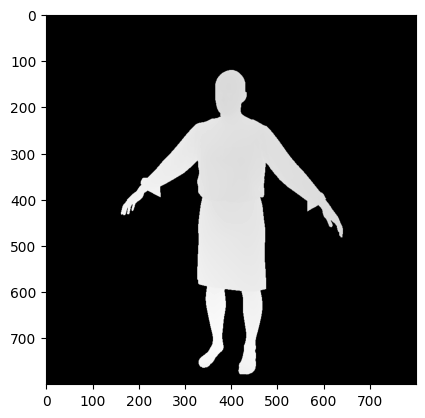

In [51]:
plt.imshow(depth_image_dict["front"])
plt.show()

In [56]:
di = depth_image_dict["front"].copy()

print(di[di > 0].max(), di[di > 0].min())



4.2439156 3.6083138


In [66]:
np.logical_or(list(stitch_vertex_mask_dict.values()))

TypeError: logical_or() takes from 2 to 3 positional arguments but 1 were given

In [379]:
# visualize_meshes_plotly(
#     [
#         simulated_garment_mesh,
#         default_body_mesh
#     ],
#     color_list=["red", "blue"],
#     vertex_list=simulated_garment_mesh.vertices[
#         np.any(
#             np.array(list(stitch_vertex_mask_dict.values())),
#             axis=0
#         )
#     ]
# )


In [14]:
# plt.imshow(rendered_image_dict["front"])
# plt.show()


In [15]:
# dii = di.copy()
# dii *= 255 / dii.max()
# dii = dii.astype(np.uint8)
# dii_rgb = cv2.cvtColor(dii, cv2.COLOR_GRAY2RGB)
# plt.imshow(dii_rgb)
# plt.show()


In [378]:
# visualize_meshes_plotly(
#     [
#         simulated_garment_mesh,
#         default_body_mesh
#     ],
#     color_list=["red", "blue"],
#     vertex_list=simulated_garment_mesh.vertices[vertex_visibility_mask_dict["front"]]
# )


In [13]:
# def create_panel_visibility_masks_and_boundaries(
#     panel_vertex_mask_dict,
#     vertex_visibility_mask,
#     projected_vertex_positions,
#     image_size=(800, 800)
# ):
#     """
#     Creates binary masks for visible portions of each panel
    
#     Args:
#         panel_vertex_mask_dict: Dict mapping panel names to vertex masks
#         vertex_visibility_mask: Boolean mask of visible vertices
#         projected_vertex_positions: 2D coordinates of projected vertices
#         image_size: Tuple of (height, width) for output masks
        
#     Returns:
#         Dict mapping panel names to binary masks
#     """
#     panel_mask_dict = {}
#     panel_boundary_dict = {}
    
#     for panel_name, panel_vertex_mask in panel_vertex_mask_dict.items():
#         # Combine panel vertex mask with visibility mask
#         visible_panel_mask = panel_vertex_mask & vertex_visibility_mask
        
#         # Get 2D coordinates of visible panel vertices
#         visible_vertices_2d = projected_vertex_positions[visible_panel_mask]
        
#         if len(visible_vertices_2d) < 3:
#             # Need at least 3 points to form a polygon
#             panel_mask_dict[panel_name] = np.zeros(image_size, dtype=np.uint8)
#             continue
            
#         # Create mask using convex hull of visible vertices
#         hull = cv2.convexHull(visible_vertices_2d.astype(np.float32))
#         boundary_vertices = hull.squeeze()
#         mask = np.zeros(image_size, dtype=np.uint8)
#         cv2.fillPoly(mask, [hull.astype(np.int32)], 1)
        
#         panel_mask_dict[panel_name] = mask
#         panel_boundary_dict[panel_name] = boundary_vertices
        
#     return panel_mask_dict, panel_boundary_dict


# for side in render_props["sides"]:
#     visibility_mask = np.array(vertex_visibility_mask_dict[side])
#     projected_positions = np.array(projected_vertex_pose_dict[side])
    
#     panel_mask_dict, panel_boundary_dict = create_panel_visibility_masks_and_boundaries(
#         panel_vertex_mask_dict,
#         visibility_mask, 
#         projected_positions,
#         image_size=(800, 800)
#     )
    
#     unique_stitch_indices = list(stitch_dict.keys())
#     colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_stitch_indices)))
#     color_dict = dict(zip(unique_stitch_indices, colors))
    
#     plt.imshow(rendered_image_dict[side])
#     for i, (panel_name, boundary_vertices) in enumerate(panel_boundary_dict.items()):
#         plt.plot(
#             boundary_vertices[:, 0], boundary_vertices[:, 1],
#             color=color_dict[i],
#             linewidth=1
#         )
#     plt.show()

In [12]:
# def create_panel_visibility_masks_and_boundaries(
#     panel_vertex_mask_dict,
#     vertex_visibility_mask,
#     projected_vertex_positions,
#     faces,
#     image_size=(800, 800)
# ):
#     """
#     Creates precise panel boundaries using mesh connectivity
    
#     Args:
#         panel_vertex_mask_dict: Dict mapping panel names to vertex masks
#         vertex_visibility_mask: Boolean mask of visible vertices
#         projected_vertex_positions: 2D coordinates of projected vertices
#         faces: Mesh face indices
#         image_size: Tuple of (height, width) for output masks
#     """
#     panel_mask_dict = {}
#     panel_boundary_dict = {}
    
#     for panel_name, panel_vertex_mask in panel_vertex_mask_dict.items():
#         # Get visible vertices for this panel
#         visible_panel_mask = panel_vertex_mask & vertex_visibility_mask
        
#         # Get faces that contain these vertices
#         panel_face_mask = np.any(visible_panel_mask[faces], axis=1)
#         panel_faces = faces[panel_face_mask]
        
#         # Get unique boundary vertices
#         boundary_vertices_2d = []
#         for face in panel_faces:
#             for i in range(3):
#                 v1, v2 = face[i], face[(i+1)%3]
#                 if visible_panel_mask[v1] and visible_panel_mask[v2]:
#                     p1 = projected_vertex_positions[v1]
#                     p2 = projected_vertex_positions[v2]
#                     boundary_vertices_2d.extend([p1, p2])
        
#         if len(boundary_vertices_2d) > 0:
#             boundary_vertices_2d = np.array(boundary_vertices_2d)
#             # Remove duplicates
#             boundary_vertices_2d = np.unique(boundary_vertices_2d, axis=0)
            
#             # Create mask
#             mask = np.zeros(image_size, dtype=np.uint8)
#             if len(boundary_vertices_2d) >= 3:
#                 # Order points to form proper boundary
#                 # You might need a more sophisticated ordering algorithm
#                 center = np.mean(boundary_vertices_2d, axis=0)
#                 angles = np.arctan2(
#                     boundary_vertices_2d[:,1] - center[1],
#                     boundary_vertices_2d[:,0] - center[0]
#                 )
#                 boundary_vertices_2d = boundary_vertices_2d[np.argsort(angles)]
                
#                 cv2.fillPoly(mask, [boundary_vertices_2d.astype(np.int32)], 1)
            
#             panel_mask_dict[panel_name] = mask
#             panel_boundary_dict[panel_name] = boundary_vertices_2d
        
#     return panel_mask_dict, panel_boundary_dict

# # Usage:
# for side in render_props["sides"]:
#     visibility_mask = np.array(vertex_visibility_mask_dict[side])
#     projected_positions = np.array(projected_vertex_pose_dict[side])
    
#     panel_mask_dict, panel_boundary_dict = create_panel_visibility_masks_and_boundaries(
#         panel_vertex_mask_dict,
#         visibility_mask, 
#         projected_positions,
#         simulated_garment_mesh.faces,
#         image_size=(800, 800)
#     )
    
#     plt.figure(figsize=(10, 5))
#     plt.subplot(1, 2, 1)
#     plt.imshow(rendered_image_dict[side])
    
#     plt.subplot(1, 2, 2)
#     plt.imshow(rendered_image_dict[side])
#     for panel_name, boundary_vertices in panel_boundary_dict.items():
#         if len(boundary_vertices) > 0:
#             # Plot the boundary
#             boundary_closed = np.vstack([boundary_vertices, boundary_vertices[0]])
#             plt.plot(
#                 boundary_closed[:, 0], 
#                 boundary_closed[:, 1],
#                 '-',
#                 linewidth=2,
#                 label=panel_name
#             )
#     plt.show()

In [11]:
# def create_panel_visibility_boundaries(
#     panel_vertex_mask_dict,
#     panel_faces_dict,
#     vertex_visibility_mask,
#     projected_vertex_positions,
# ):
#     """
#     Finds boundary vertices of visible panel regions
    
#     Args:
#         panel_vertex_mask_dict: Dict mapping panel names to vertex masks
#         panel_faces_dict: Dict mapping panel names to their faces
#         vertex_visibility_mask: Boolean mask of visible vertices
#         projected_vertex_positions: 2D coordinates of projected vertices
#     """
#     panel_boundary_dict = {}
    
#     for panel_name, panel_vertex_mask in panel_vertex_mask_dict.items():
#         panel_faces = panel_faces_dict[panel_name]
        
#         if len(panel_faces) == 0:
#             panel_boundary_dict[panel_name] = []
#             continue
            
#         # Get visible vertices for this panel
#         visible_panel_mask = panel_vertex_mask & vertex_visibility_mask
        
#         # Create edge set to find boundary edges
#         edge_set = set()  # All edges
#         boundary_edges = set()  # Edges that appear only once (boundary)
        
#         for face in panel_faces:
#             for i in range(3):
#                 v1, v2 = face[i], face[(i+1)%3]
#                 if visible_panel_mask[v1] and visible_panel_mask[v2]:
#                     # Order vertices to ensure consistent edge representation
#                     edge = tuple(sorted([v1, v2]))
#                     if edge in edge_set:
#                         # If edge appears twice, it's not a boundary
#                         boundary_edges.discard(edge)
#                     else:
#                         edge_set.add(edge)
#                         boundary_edges.add(edge)
        
#         # Convert boundary edges to ordered boundary vertices
#         if len(boundary_edges) > 0:
#             # Convert edges to vertex list
#             boundary_vertices = []
#             current_edge = list(boundary_edges.pop())
#             boundary_vertices.extend(current_edge)
            
#             while boundary_edges:
#                 # Find next edge that connects to current edge
#                 current_vertex = boundary_vertices[-1]
#                 next_edge = None
                
#                 for edge in boundary_edges:
#                     if current_vertex in edge:
#                         next_edge = edge
#                         next_vertex = edge[0] if edge[1] == current_vertex else edge[1]
#                         break
                
#                 if next_edge is None:
#                     # Start new chain if no connecting edge found
#                     next_edge = list(boundary_edges.pop())
#                     boundary_vertices.extend(next_edge)
#                 else:
#                     boundary_edges.remove(next_edge)
#                     boundary_vertices.append(next_vertex)
            
#             # Convert vertex indices to 2D coordinates
#             boundary_coords = projected_vertex_positions[boundary_vertices]
#             panel_boundary_dict[panel_name] = [boundary_coords]
#         else:
#             panel_boundary_dict[panel_name] = []
    
#     return panel_boundary_dict

# # Usage:
# for side in render_props["sides"]:
#     visibility_mask = np.array(vertex_visibility_mask_dict[side])
#     projected_positions = np.array(projected_vertex_pose_dict[side])
    
#     panel_boundary_dict = create_panel_visibility_boundaries(
#         panel_vertex_mask_dict,
#         panel_faces_dict,
#         visibility_mask, 
#         projected_positions
#     )
    
#     # Visualize
#     plt.figure(figsize=(10, 10))
#     plt.imshow(rendered_image_dict[side])
    
#     for panel_name, boundaries in panel_boundary_dict.items():
#         for boundary_vertices in boundaries:
#             boundary_closed = np.vstack([boundary_vertices, boundary_vertices[0]])
#             plt.plot(
#                 boundary_closed[:, 0], 
#                 boundary_closed[:, 1],
#                 '-',
#                 linewidth=2,
#                 label=f"{panel_name}"
#             )
#             # Optionally plot boundary vertices
#             plt.scatter(
#                 boundary_vertices[:, 0],
#                 boundary_vertices[:, 1],
#                 s=20
#             )
    
#     plt.title(f"Panel Boundaries - {side} view")
#     plt.legend()
#     plt.show()

In [10]:
# def create_panel_visibility_boundaries(
#     panel_vertex_mask_dict,
#     panel_faces_dict,
#     vertex_visibility_mask,
#     projected_vertex_positions,
# ):
#     """
#     Finds ordered boundary loops for visible panel regions
#     """
#     panel_boundary_dict = {}
    
#     for panel_name, panel_vertex_mask in panel_vertex_mask_dict.items():
#         panel_faces = panel_faces_dict[panel_name]
        
#         if len(panel_faces) == 0:
#             panel_boundary_dict[panel_name] = []
#             continue
            
#         visible_panel_mask = panel_vertex_mask & vertex_visibility_mask
        
#         # Create edge count dictionary to find boundary edges
#         edge_count = {}
#         boundary_vertices = set()
        
#         # Count edge occurrences and collect boundary vertices
#         for face in panel_faces:
#             for i in range(3):
#                 v1, v2 = face[i], face[(i+1)%3]
#                 if visible_panel_mask[v1] and visible_panel_mask[v2]:
#                     edge = tuple(sorted([v1, v2]))
#                     edge_count[edge] = edge_count.get(edge, 0) + 1
        
#         # Get boundary edges (those appearing once)
#         boundary_edges = [edge for edge, count in edge_count.items() if count == 1]
        
#         if not boundary_edges:
#             panel_boundary_dict[panel_name] = []
#             continue
            
#         # Create ordered loops from boundary edges
#         loops = []
#         remaining_edges = set(boundary_edges)
        
#         while remaining_edges:
#             # Start new loop
#             current_edge = remaining_edges.pop()
#             loop = list(current_edge)
            
#             while True:
#                 # Find next connected edge
#                 found_next = False
#                 current_vertex = loop[-1]
                
#                 for edge in remaining_edges:
#                     if current_vertex in edge:
#                         next_vertex = edge[0] if edge[1] == current_vertex else edge[1]
#                         if next_vertex != loop[0]:  # Avoid premature loop closure
#                             loop.append(next_vertex)
#                             remaining_edges.remove(edge)
#                             found_next = True
#                             break
                
#                 if not found_next:
#                     # If loop is closed (last vertex connects to first)
#                     if any(current_vertex in edge and loop[0] in edge for edge in remaining_edges):
#                         loop.append(loop[0])  # Close the loop
#                     break
            
#             if len(loop) >= 4:  # Only keep valid loops (at least 3 vertices + closing vertex)
#                 # Convert to 2D coordinates
#                 loop_coords = projected_vertex_positions[loop]
#                 loops.append(loop_coords)
        
#         panel_boundary_dict[panel_name] = loops
    
#     return panel_boundary_dict

# # Usage:
# for side in render_props["sides"]:
#     visibility_mask = np.array(vertex_visibility_mask_dict[side])
#     projected_positions = np.array(projected_vertex_pose_dict[side])
    
#     panel_boundary_dict = create_panel_visibility_boundaries(
#         panel_vertex_mask_dict,
#         panel_faces_dict,
#         visibility_mask, 
#         projected_positions
#     )
    
#     # Visualize
#     plt.figure(figsize=(10, 10))
#     plt.imshow(rendered_image_dict[side])
    
#     for panel_name, boundaries in panel_boundary_dict.items():
#         for boundary_vertices in boundaries:
#             plt.plot(
#                 boundary_vertices[:, 0], 
#                 boundary_vertices[:, 1],
#                 '-',
#                 linewidth=2,
#                 label=f"{panel_name}"
#             )
#             # Plot vertices
#             plt.scatter(
#                 boundary_vertices[:, 0],
#                 boundary_vertices[:, 1],
#                 s=20
#             )
    
#     plt.title(f"Panel Boundaries - {side} view")
#     plt.legend()
#     plt.show()

In [9]:
# def create_panel_visibility_boundaries(
#     panel_vertex_mask_dict,
#     vertex_visibility_mask,
#     projected_vertex_positions,
#     faces,
#     image_size=(800, 800)
# ):
#     """
#     Creates precise panel boundaries, handling split/disconnected regions
    
#     Args:
#         panel_vertex_mask_dict: Dict mapping panel names to vertex masks
#         vertex_visibility_mask: Boolean mask of visible vertices
#         projected_vertex_positions: 2D coordinates of projected vertices
#         faces: Mesh face indices
#         image_size: Tuple of (height, width) for output masks
#     """
#     panel_boundary_dict = {}
    
#     for panel_name, panel_vertex_mask in panel_vertex_mask_dict.items():
#         # Get visible vertices for this panel
#         visible_panel_mask = panel_vertex_mask & vertex_visibility_mask
        
#         # Get faces that contain these vertices
#         panel_face_mask = np.any(visible_panel_mask[faces], axis=1)
#         panel_faces = faces[panel_face_mask]
        
#         # Create graph of connected vertices
#         from scipy.sparse import csr_matrix
#         from scipy.sparse.csgraph import connected_components
        
#         # Create adjacency matrix
#         n_vertices = len(projected_vertex_positions)
#         adj_matrix = np.zeros((n_vertices, n_vertices))
        
#         for face in panel_faces:
#             for i in range(3):
#                 v1, v2 = face[i], face[(i+1)%3]
#                 if visible_panel_mask[v1] and visible_panel_mask[v2]:
#                     # Add edge to adjacency matrix
#                     adj_matrix[v1, v2] = 1
#                     adj_matrix[v2, v1] = 1
        
#         # Find connected components
#         n_components, labels = connected_components(
#             csr_matrix(adj_matrix),
#             directed=False
#         )
        
#         # Process each connected component separately
#         panel_boundaries = []
#         for comp_idx in range(n_components):
#             comp_vertex_mask = (labels == comp_idx) & visible_panel_mask
#             if not np.any(comp_vertex_mask):
#                 continue
                
#             # Get boundary edges for this component
#             boundary_vertices_2d = []
#             for face in panel_faces:
#                 for i in range(3):
#                     v1, v2 = face[i], face[(i+1)%3]
#                     if comp_vertex_mask[v1] and comp_vertex_mask[v2]:
#                         p1 = projected_vertex_positions[v1]
#                         p2 = projected_vertex_positions[v2]
#                         boundary_vertices_2d.extend([p1, p2])
            
#             if len(boundary_vertices_2d) > 0:
#                 boundary_vertices_2d = np.array(boundary_vertices_2d)
#                 # Remove duplicates
#                 boundary_vertices_2d = np.unique(boundary_vertices_2d, axis=0)
                
#                 if len(boundary_vertices_2d) >= 3:
#                     # Order points to form proper boundary
#                     center = np.mean(boundary_vertices_2d, axis=0)
#                     angles = np.arctan2(
#                         boundary_vertices_2d[:,1] - center[1],
#                         boundary_vertices_2d[:,0] - center[0]
#                     )
#                     boundary_vertices_2d = boundary_vertices_2d[np.argsort(angles)]
#                     panel_boundaries.append(boundary_vertices_2d)
        
#         panel_boundary_dict[panel_name] = panel_boundaries
    
#     return panel_boundary_dict

# # Usage:
# for side in render_props["sides"]:
#     visibility_mask = np.array(vertex_visibility_mask_dict[side])
#     projected_positions = np.array(projected_vertex_pose_dict[side])
    
#     panel_boundary_dict = create_panel_visibility_boundaries(
#         panel_vertex_mask_dict,
#         visibility_mask, 
#         projected_positions,
#         simulated_garment_mesh.faces
#     )
    
#     # Visualize
#     plt.figure(figsize=(10, 10))
#     plt.imshow(rendered_image_dict[side])
    
#     for panel_name, boundaries in panel_boundary_dict.items():
#         for boundary_vertices in boundaries:  # Now handles multiple polygons per panel
#             boundary_closed = np.vstack([boundary_vertices, boundary_vertices[0]])
#             plt.plot(
#                 boundary_closed[:, 0], 
#                 boundary_closed[:, 1],
#                 '-',
#                 linewidth=2,
#                 label=f"{panel_name}"
#             )
    
#     plt.title(f"Panel Boundaries - {side} view")
#     plt.legend()
#     plt.show()

In [66]:
print("3D vertices",        np.array(simulated_garment_mesh.vertices).shape)
print("faces",              np.array(simulated_garment_mesh.faces).shape)
print("visibility mask",    np.array(vertex_visibility_mask_dict["front"]).shape)
print("projected vertices", np.array(projected_vertex_pose_dict["front"]).shape)

3D vertices (23186, 3)
faces (44054, 3)
visibility mask (23186,)
projected vertices (23186, 2)


In [69]:
visibility = np.array(vertex_visibility_mask_dict["front"]) == True
visible_indices = np.where(visibility)

In [71]:
len(visible_indices)

1

In [80]:
import numpy as np
from scipy.spatial import ConvexHull
from shapely.geometry import Polygon, MultiPolygon
import networkx as nx

SIDE = "front"

vertices_3d = np.array([simulated_garment_mesh.vertices])[0]

faces = np.array([simulated_garment_mesh.faces])[0]

proj_vertices_2d = np.array(projected_vertex_pose_dict[SIDE])

visibility = np.array(vertex_visibility_mask_dict[SIDE])

# Step 1: Filter visible vertices
visible_indices = np.where(visibility == True)[0]  # Indices of visible vertices
visible_proj = proj_vertices_2d[visible_indices]  # 2D positions of visible vertices

# Step 2: Build adjacency graph using face connections
graph = nx.Graph()

for face in faces:
    for i in range(3):
        v1, v2 = face[i], face[(i + 1) % 3]  # Edges in triangle
        if visibility[v1] and visibility[v2]:  # Only add visible edges
            graph.add_edge(v1, v2)

# Step 3: Find connected components of visible vertices
connected_components = [list(c) for c in nx.connected_components(graph)]

# Step 4: Compute polygons for each connected component
polygons = []
for component in connected_components:
    # Extract 2D positions of vertices in this component
    points = proj_vertices_2d[component]
    if len(points) < 3:  # Skip degenerate cases
        continue

    # Compute Convex Hull for boundary
    hull = ConvexHull(points)  # Boundary points
    hull_points = points[hull.vertices]

    # Create Polygon
    polygons.append(Polygon(hull_points))

# Final result: MultiPolygon for all visible regions
polygons_result = MultiPolygon(polygons)

# Output
print("Polygons Result:", polygons_result)

Polygons Result: MULTIPOLYGON (((337.9209943251873 429.05169463886443, 355.9366168032287 587.683849124976, 354.8152267240876 589.4744528904246, 331.82585197318207 617.8775092025235, 324.52080595676404 616.7370611055541, 321.8830823480475 615.427750955942, 321.32943517977924 610.9761445831001, 321.11876769263074 607.9319056541048, 321.20886139085997 538.9651037909957, 322.1821262350938 500.173689913267, 323.09009228181196 483.62829303622703, 325.324338636871 461.9562912909781, 332.56492654344186 427.01543462280716, 333.6861579574787 424.68075259891293, 337.9209943251873 429.05169463886443)), ((324.5321495108371 471.74117898051907, 325.75473658089686 468.84324095239447, 325.46241676796495 473.60171244590384, 324.5321495108371 471.74117898051907)), ((376.20001299897103 461.61780591330603, 375.5065813740602 630.5471963930808, 364.3307599728486 635.2206829191629, 361.2196550781599 635.1058551790486, 330.6945408750895 616.8550578381975, 327.83522921413385 614.5189629255221, 332.2594212871483

In [81]:
type(polygons_result)

shapely.geometry.multipolygon.MultiPolygon

In [8]:

# # Visualization
# fig, ax = plt.subplots(figsize=(20, 20))

# # Plot all projected vertices
# ax.scatter(proj_vertices_2d[:, 0], proj_vertices_2d[:, 1], c='gray', label='Projected Vertices')

# # Highlight visible vertices
# ax.scatter(visible_proj[:, 0], visible_proj[:, 1], c='blue', label='Visible Vertices')

# # Plot the polygons
# for poly in polygons:
#     x, y = poly.exterior.xy
#     ax.plot(x, y, 'r-', label='Polygon Boundary')

# # Configure plot
# ax.set_aspect('equal')
# ax.set_xlabel('u (image plane x-axis)')
# ax.set_ylabel('v (image plane y-axis)')
# ax.legend()
# ax.grid(True)
# plt.title('Projected Vertices and Polygon Boundaries')
# plt.show()

In [7]:
# import numpy as np
# import matplotlib.pyplot as plt
# from shapely.geometry import Polygon, MultiPolygon, Point
# from scipy.spatial import Delaunay
# import networkx as nx

# # Function to compute alpha shape
# def alpha_shape(points, alpha):
#     """
#     Compute the alpha shape (concave hull) of a set of points.
#     :param points: np.array of shape (N, 2) representing 2D coordinates.
#     :param alpha: Alpha value controlling shape tightness (smaller = tighter).
#     :return: List of polygons representing the alpha shape.
#     """
#     if len(points) < 4:  # Convex hull for less than 4 points
#         return [Polygon(points)]

#     # Delaunay triangulation
#     tri = Delaunay(points)
#     edges = set()
#     for simplex in tri.simplices:
#         for i in range(3):
#             j = (i + 1) % 3
#             edge = tuple(sorted([simplex[i], simplex[j]]))
#             # Calculate edge length
#             if np.linalg.norm(points[edge[0]] - points[edge[1]]) < alpha:
#                 edges.add(edge)

#     # Create graph and extract boundary cycles
#     graph = nx.Graph(list(edges))
#     cycles = list(nx.connected_components(graph))

#     # Create polygons from cycles
#     polygons = []
#     for cycle in cycles:
#         hull_points = points[list(cycle)]
#         polygons.append(Polygon(hull_points))
#     return polygons




# # Example Input
# Nv = 8
# vertices_3d = np.array([
#     [0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0],  # Square 1
#     [2, 2, 0], [3, 2, 0], [3, 3, 0], [2, 3, 0]   # Square 2 (Disconnected)
# ])
# faces = np.array([[0, 1, 2], [0, 2, 3], [4, 5, 6], [4, 6, 7]])
# proj_vertices_2d = vertices_3d[:, :2]  # Projection (x, y)
# visibility = np.array([1, 1, 1, 1, 1, 1, 1, 1])  # All visible

# # Filter visible vertices
# visible_indices = np.where(visibility == 1)[0]
# visible_proj = proj_vertices_2d[visible_indices]

# # Graph for connected components
# graph = nx.Graph()
# for face in faces:
#     for i in range(3):
#         v1, v2 = face[i], face[(i + 1) % 3]
#         if visibility[v1] and visibility[v2]:
#             graph.add_edge(v1, v2)

# connected_components = [list(c) for c in nx.connected_components(graph)]

# # Alpha Shape Boundary for each component
# alpha = 1.5  # Adjust this parameter to control concavity
# polygons = []
# for component in connected_components:
#     points = proj_vertices_2d[component]
#     if len(points) < 3:
#         continue
#     polygons += alpha_shape(points, alpha)

# # Visualization
# fig, ax = plt.subplots(figsize=(6, 6))

# # Plot all vertices
# ax.scatter(proj_vertices_2d[:, 0], proj_vertices_2d[:, 1], c='gray', label='Projected Vertices')

# # Highlight visible vertices
# ax.scatter(visible_proj[:, 0], visible_proj[:, 1], c='blue', label='Visible Vertices')

# # Plot the alpha shape polygons
# for poly in polygons:
#     if poly.is_valid:  # Check if the polygon is valid
#         x, y = poly.exterior.xy
#         ax.plot(x, y, 'r-', label='Polygon Boundary')

# # Configure plot
# ax.set_aspect('equal')
# ax.set_xlabel('u (image plane x-axis)')
# ax.set_ylabel('v (image plane y-axis)')
# ax.legend()
# ax.grid(True)
# plt.title('Alpha Shapes for Visible Regions')
# plt.show()

In [6]:
# import numpy as np
# import matplotlib.pyplot as plt
# from shapely.geometry import Polygon, MultiPolygon
# from scipy.spatial import Delaunay
# import networkx as nx

# SIDE = "front"

# # Input data
# vertices_3d = np.array([simulated_garment_mesh.vertices])[0]  # 3D vertices
# faces = np.array([simulated_garment_mesh.faces])[0]  # Faces
# proj_vertices_2d = np.array(projected_vertex_pose_dict[SIDE])  # 2D projections
# visibility = np.array(vertex_visibility_mask_dict[SIDE])  # Visibility mask

# # Step 1: Filter visible vertices
# visible_indices = np.where(visibility == True)[0]  # Visible indices
# visible_proj = proj_vertices_2d[visible_indices]  # 2D positions of visible vertices

# # Step 2: Build adjacency graph using face connections
# graph = nx.Graph()
# for face in faces:
#     for i in range(3):
#         v1, v2 = face[i], face[(i + 1) % 3]
#         if visibility[v1] and visibility[v2]:  # Only add visible edges
#             graph.add_edge(v1, v2)

# # Step 3: Find connected components of visible vertices
# connected_components = [list(c) for c in nx.connected_components(graph)]

# # Function to compute alpha shapes (concave hull)
# def alpha_shape(points, alpha):
#     """
#     Compute alpha shape (concave hull) for given points.
#     :param points: np.array of shape (N, 2).
#     :param alpha: Tightness parameter for the shape.
#     :return: List of polygons.
#     """
#     if len(points) < 4:  # Use convex hull for fewer points
#         return [Polygon(points)]

#     # Delaunay triangulation
#     tri = Delaunay(points)
#     edges = set()
#     for simplex in tri.simplices:
#         for i in range(3):
#             j = (i + 1) % 3
#             edge = tuple(sorted([simplex[i], simplex[j]]))
#             # Compute edge length
#             if np.linalg.norm(points[edge[0]] - points[edge[1]]) < alpha:
#                 edges.add(edge)

#     # Create graph and extract cycles
#     graph = nx.Graph(list(edges))
#     cycles = list(nx.connected_components(graph))

#     # Form polygons from cycles
#     polygons = []
#     for cycle in cycles:
#         hull_points = points[list(cycle)]
#         polygons.append(Polygon(hull_points))
#     return polygons

# # Step 4: Compute alpha shapes for each connected component
# alpha = 10  # Alpha controls tightness; tune based on data
# polygons = []
# for component in connected_components:
#     points = proj_vertices_2d[component]  # Extract 2D points for this component
#     if len(points) < 3:
#         continue  # Skip small components
#     polygons += alpha_shape(points, alpha)

# # Final result: MultiPolygon for all visible regions
# polygons_result = MultiPolygon(polygons)

# # Visualization
# fig, ax = plt.subplots(figsize=(10, 10))

# # Plot projected vertices
# ax.scatter(proj_vertices_2d[:, 0], proj_vertices_2d[:, 1], c='gray', label='Projected Vertices')
# ax.scatter(visible_proj[:, 0], visible_proj[:, 1], c='blue', label='Visible Vertices')

# # Plot polygons
# for poly in polygons:
#     if poly.is_valid:  # Ensure valid polygons
#         x, y = poly.exterior.xy
#         ax.plot(x, y, 'r-', label='Polygon Boundary')

# # Configure plot
# ax.set_aspect('equal')
# ax.set_xlabel('u (image plane x-axis)')
# ax.set_ylabel('v (image plane y-axis)')
# ax.legend()
# ax.grid(True)
# plt.title('Projected Vertices and Alpha Shape Boundaries')
# plt.show()

In [95]:
panel_vertex_mask_dict["skirt_panel_0"].shape

(23186,)

In [41]:
panel_vertex_mask_dict

{'sl_right_cuff_skirt_b': array([False, False, False, ..., False, False, False]),
 'sl_right_cuff_skirt_f': array([False, False, False, ..., False, False, False]),
 'right_sleeve_b': array([False, False, False, ..., False, False, False]),
 'right_sleeve_f': array([False, False, False, ..., False, False, False]),
 'right_btorso': array([False, False, False, ..., False, False, False]),
 'right_ftorso': array([False, False, False, ..., False, False, False]),
 'skirt_back': array([False, False, False, ..., False, False, False]),
 'skirt_front': array([False, False, False, ..., False, False, False]),
 'left_btorso': array([False, False, False, ..., False, False, False]),
 'left_ftorso': array([False, False, False, ..., False, False, False]),
 'left_sleeve_b': array([False, False, False, ..., False, False, False]),
 'left_sleeve_f': array([False, False, False, ..., False, False, False]),
 'sl_left_cuff_skirt_b': array([False, False, False, ..., False, False, False]),
 'sl_left_cuff_skirt_f':

In [5]:
# import numpy as np
# import matplotlib.pyplot as plt
# from shapely.geometry import Polygon, MultiPolygon
# from scipy.spatial import Delaunay
# import networkx as nx

# SIDE = "front"

# # Input Data
# vertices_3d = np.array([simulated_garment_mesh.vertices])[0]  # 3D vertices
# faces = np.array([simulated_garment_mesh.faces])[0]  # Faces
# proj_vertices_2d = np.array(projected_vertex_pose_dict[SIDE])  # 2D projections
# visibility = np.array(vertex_visibility_mask_dict[SIDE])  # Visibility mask
# panel_masks = panel_vertex_mask_dict  # Dictionary for panel-wise masks


# def alpha_shape(points, alpha):
#     """
#     Compute alpha shape (concave hull) for given points.
#     :param points: np.array of shape (N, 2).
#     :param alpha: Tightness parameter for the shape.
#     :return: List of polygons.
#     """
#     if len(points) < 4:  # Convex hull for fewer points
#         return [Polygon(points)]

#     # Delaunay triangulation
#     tri = Delaunay(points)
#     edges = set()
#     for simplex in tri.simplices:
#         for i in range(3):
#             j = (i + 1) % 3
#             edge = tuple(sorted([simplex[i], simplex[j]]))
#             # Compute edge length
#             if np.linalg.norm(points[edge[0]] - points[edge[1]]) < alpha:
#                 edges.add(edge)

#     # Create graph and extract cycles
#     graph = nx.Graph(list(edges))
#     cycles = list(nx.connected_components(graph))

#     # Form polygons from cycles
#     polygons = []
#     for cycle in cycles:
#         hull_points = points[list(cycle)]
#         polygons.append(Polygon(hull_points))
#     return polygons

# # Visualization setup
# fig, ax = plt.subplots(figsize=(10, 10))

# # Plot all projected vertices
# ax.scatter(proj_vertices_2d[:, 0], proj_vertices_2d[:, 1], c='gray', label='Projected Vertices')

# # Store results for all panels
# panel_polygons = {}

# # Process each panel
# alpha = 10  # Adjust alpha for concavity
# for panel_name, mask in panel_masks.items():
#     # Step 1: Filter vertices belonging to this panel and visible
#     panel_indices = np.where(mask & visibility)[0]  # Panel + visible mask
#     panel_proj = proj_vertices_2d[panel_indices]  # 2D positions for this panel

#     # Step 2: Build adjacency graph based on face connectivity
#     graph = nx.Graph()
#     for face in faces:
#         for i in range(3):
#             v1, v2 = face[i], face[(i + 1) % 3]
#             if v1 in panel_indices and v2 in panel_indices:  # Only add panel edges
#                 graph.add_edge(v1, v2)

#     # Step 3: Find connected components (handle disconnections)
#     connected_components = [list(c) for c in nx.connected_components(graph)]

#     # Step 4: Compute alpha shapes for each connected component
#     polygons = []
#     for component in connected_components:
#         points = proj_vertices_2d[component]  # Extract 2D points for this component
#         if len(points) < 3:
#             continue  # Skip degenerate cases
#         polygons += alpha_shape(points, alpha)

#     # Store results for this panel
#     panel_polygons[panel_name] = MultiPolygon(polygons)

#     # Plot polygons for visualization
#     for poly in polygons:
#         if poly.is_valid:  # Ensure polygon validity
#             x, y = poly.exterior.xy
#             ax.plot(x, y, label=f'{panel_name} Boundary')

# # Finalize visualization
# ax.set_aspect('equal')
# ax.set_xlabel('u (image plane x-axis)')
# ax.set_ylabel('v (image plane y-axis)')
# ax.legend()
# ax.grid(True)
# plt.title('Segmented Panels with Alpha Shape Boundaries')
# plt.show()

# # Output final panel polygons
# print("Panel Polygons:")
# for panel_name, poly in panel_polygons.items():
#     print(f"{panel_name}: {poly}")

In [27]:
for panel_name, multi_polygon in panel_polygons.items():
    try :
        for polygon in multi_polygon:
            print(polygon)
    except Exception as e:
        print(f"Error for {panel_name}: {e}")
    print()

Error for sl_right_cuff_skirt_b: 'MultiPolygon' object is not iterable

Error for sl_right_cuff_skirt_f: 'MultiPolygon' object is not iterable

Error for right_sleeve_b: 'MultiPolygon' object is not iterable

Error for right_sleeve_f: 'MultiPolygon' object is not iterable

Error for right_btorso: 'MultiPolygon' object is not iterable

Error for right_ftorso: 'MultiPolygon' object is not iterable

Error for skirt_back: 'MultiPolygon' object is not iterable

Error for skirt_front: 'MultiPolygon' object is not iterable

Error for left_btorso: 'MultiPolygon' object is not iterable

Error for left_ftorso: 'MultiPolygon' object is not iterable

Error for left_sleeve_b: 'MultiPolygon' object is not iterable

Error for left_sleeve_f: 'MultiPolygon' object is not iterable

Error for sl_left_cuff_skirt_b: 'MultiPolygon' object is not iterable

Error for sl_left_cuff_skirt_f: 'MultiPolygon' object is not iterable



In [30]:
render_props["sides"]

['front', 'back', 'right', 'left']

In [40]:
panel_polygons


{'sl_right_cuff_skirt_b': <MULTIPOLYGON (((211.663 358.51, 212.197 357.084, 218.836 355.746, 216.891 3...>,
 'sl_right_cuff_skirt_f': <MULTIPOLYGON (((206.041 369.155, 207.105 371.608, 208.904 374.344, 211.475 ...>,
 'right_sleeve_b': <MULTIPOLYGON (((252.073 321.17, 254.456 319.17, 249.538 322.57, 256.46 317....>,
 'right_sleeve_f': <MULTIPOLYGON (((303.735 306.014, 279.83 330.257, 258.004 348.271, 313.55 27...>,
 'right_btorso': <MULTIPOLYGON (((358.173 228.309, 355.368 229.059, 367.461 225.529, 360.941 ...>,
 'right_ftorso': <MULTIPOLYGON (((370.21 326.214, 331.002 349.26, 344.198 247.236, 346.985 25...>,
 'skirt_back': <MULTIPOLYGON (((327.339 573.011, 327.192 569.639, 327.087 566.269, 327.027 ...>,
 'skirt_front': <MULTIPOLYGON (((349.17 589.37, 352.495 589.983, 355.863 590.563, 359.273 59...>,
 'left_btorso': <MULTIPOLYGON (((451.398 231.708, 455.437 232.362, 460.157 235.207, 456.746 ...>,
 'left_ftorso': <MULTIPOLYGON (((449.14 234.511, 449.427 234.333, 448.205 237.337, 446.981 

In [4]:
# import numpy as np
# import matplotlib.pyplot as plt
# from shapely.geometry import Polygon, MultiPolygon
# import random



# # Create color map for panels
# def generate_distinct_colors(n):
#     colors = plt.cm.rainbow(np.linspace(0, 1, n))
#     return colors


# FIGLEN = 7
# NCOLS = 2 # len(render_props["sides"])
# NROWS = 1

# # plt.figure(figsize=(FIGLEN * NCOLS, FIGLEN * NROWS))
# for i, side in enumerate(render_props["sides"]):
#     plt.figure(figsize=(FIGLEN * NCOLS, FIGLEN * NROWS))
#     plt.subplot(NROWS, NCOLS, 1)
#     plt.imshow(rendered_image_dict[side])


#     ax = plt.subplot(NROWS, NCOLS, 2)
#     ax.imshow(rendered_image_dict[side])

#     # Get colors for each panel
#     panel_colors = generate_distinct_colors(len(panel_polygons))

#     # Plot each panel's boundaries
#     for (panel_name, multi_polygon), color in zip(panel_polygons.items(), panel_colors):
        
        
#         # Handle both single polygons and multipolygons
#         if isinstance(multi_polygon, Polygon):
#             polygons = [multi_polygon]
#         else:
#             polygons = list(multi_polygon.geoms)
        
#         # Plot each polygon in the multipolygon
#         for polygon in polygons:
#             # Get exterior coordinates
            
#             x, y = polygon.exterior.xy
#             ax.plot(x, y, '-', color=color, linewidth=2, label=panel_name)
            
#             # # Plot interior rings (holes) if any
#             # for interior in polygon.interiors:
#             #     x, y = interior.xy
#             #     plt.plot(x, y, '--', color=color, linewidth=1)

#     ax.set_title(f'Panel Boundaries - {side} view')
#     ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#     ax.axis('equal')
#     plt.tight_layout()
#     plt.show()

In [110]:
list(multi_polygon.geoms)[0].exterior.xy

(array('d', [475.7056788363297, 475.48373444683244, 478.33811139831363, 472.2259001110626, 475.29770242530384, 475.0612721521887, 470.66640373860207, 472.89322762258183, 479.87602646168057, 476.2386232333783, 475.11695909840165, 475.4180597417361, 474.8068171204077, 473.76026319263616, 475.5182896334967, 469.4294441662188, 476.0430454224915, 476.1702626353606, 472.52716960502886, 466.41557178327326, 481.652200756153, 473.077415290678, 474.94697776138037, 469.65514348419043, 469.8768721232784, 478.2293206828323, 472.13947754264734, 471.9833908600988, 472.17419924270905, 474.5589543462807, 478.25266187505395, 474.8615290562266, 475.51929071152495, 480.4425680502787, 475.4303819312882, 472.42525785107193, 475.60725065037957, 469.914970969363, 477.5550605809615, 473.403094729223, 475.94413090875116, 476.0607669846062, 467.57376169935344, 474.2991246631408, 476.38692951016975, 477.75539507849453, 480.34765326537627, 479.3425956423137, 471.1567401063871, 470.64796557790896, 473.9047123051913

In [3]:
# import numpy as np
# import matplotlib.pyplot as plt
# from shapely.geometry import Polygon, MultiPolygon, LineString
# from scipy.spatial import Delaunay
# import networkx as nx

# # Setup inputs
# SIDE = "front"

# # Inputs: Replace these with your actual data
# vertices_3d = np.array([simulated_garment_mesh.vertices])[0]  # 3D vertices
# faces = np.array([simulated_garment_mesh.faces])[0]  # Faces
# proj_vertices_2d = np.array(projected_vertex_pose_dict[SIDE])  # 2D projections
# visibility = np.array(vertex_visibility_mask_dict[SIDE])  # Visibility mask
# panel_masks = panel_vertex_mask_dict  # Dictionary for per-panel masks
# image = rendered_image_dict[SIDE]  # Rendered image

# # Function to compute boundary edges
# def extract_boundary(points):
#     """
#     Compute the boundary points of a region using Delaunay triangulation.
#     This avoids internal points and keeps only edges forming a tight boundary.
#     """
#     # Compute Delaunay triangulation
#     tri = Delaunay(points)

#     # Collect edges (pairs of vertices)
#     edges = set()
#     for simplex in tri.simplices:
#         for i in range(3):
#             j = (i + 1) % 3
#             edge = tuple(sorted([simplex[i], simplex[j]]))
#             edges.add(edge)

#     # Create graph and find boundary cycles
#     graph = nx.Graph(list(edges))
#     boundary = [list(c) for c in nx.connected_components(graph)]
    
#     # Convert to boundary points
#     boundary_points = []
#     for component in boundary:
#         cycle = points[component]
#         hull = Polygon(cycle).convex_hull  # Ensure convex boundary
#         boundary_points.append(hull.exterior.coords)
#     return boundary_points

# # Visualization setup
# fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# # Show rendered image on both views
# ax[0].imshow(image)
# ax[1].imshow(image)

# # Generate distinct colors for each panel
# def generate_distinct_colors(n):
#     colors = plt.cm.rainbow(np.linspace(0, 1, n))
#     return colors

# panel_colors = generate_distinct_colors(len(panel_masks))

# # Process each panel
# for (panel_name, mask), color in zip(panel_masks.items(), panel_colors):
#     # Step 1: Filter visible and masked vertices
#     panel_indices = np.where(mask & visibility)[0]  # Combine panel + visibility mask
#     panel_proj = proj_vertices_2d[panel_indices]  # Extract 2D positions

#     if len(panel_proj) < 3:  # Skip small panels
#         continue

#     # Step 2: Extract boundary points
#     boundaries = extract_boundary(panel_proj)

#     # Step 3: Plot boundaries only (no internal points)
#     for boundary in boundaries:
#         boundary = np.array(boundary)
#         ax[1].plot(boundary[:, 0], boundary[:, 1], '-', color=color, linewidth=2, label=panel_name)

# # Finalize visualization
# ax[1].set_title(f'Panel Boundaries - {SIDE} view')
# ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# ax[1].axis('equal')

# ax[0].set_title(f'Rendered Image - {SIDE} view')
# ax[0].axis('equal')

# plt.tight_layout()
# plt.show()

In [2]:
# import numpy as np
# import matplotlib.pyplot as plt
# from shapely.geometry import Polygon, MultiPolygon, LineString
# from scipy.spatial import Delaunay
# import networkx as nx

# SIDE = "front"

# # Inputs: Replace these with actual data
# vertices_3d = np.array([simulated_garment_mesh.vertices])[0]
# faces = np.array([simulated_garment_mesh.faces])[0]
# proj_vertices_2d = np.array(projected_vertex_pose_dict[SIDE])
# visibility = np.array(vertex_visibility_mask_dict[SIDE])
# panel_masks = panel_vertex_mask_dict  # Dictionary for per-panel masks
# image = rendered_image_dict[SIDE]

# # Alpha Shape function for tighter, non-convex boundaries
# def alpha_shape(points, alpha):
#     """
#     Compute alpha shape (concave hull) for a set of points.
#     """
#     if len(points) < 4:  # Use convex hull for fewer points
#         return Polygon(points)

#     tri = Delaunay(points)
#     edges = set()
#     for simplex in tri.simplices:
#         for i in range(3):
#             j = (i + 1) % 3
#             edge = tuple(sorted([simplex[i], simplex[j]]))
#             if np.linalg.norm(points[edge[0]] - points[edge[1]]) < alpha:
#                 edges.add(edge)

#     graph = nx.Graph(list(edges))
#     boundary = list(nx.connected_components(graph))

#     # Generate polygons from boundaries
#     polygons = []
#     for component in boundary:
#         hull_points = points[list(component)]
#         hull = Polygon(hull_points).convex_hull  # Tighten boundaries
#         polygons.append(hull)
#     return MultiPolygon(polygons)

# # Densify boundary points by interpolating along edges
# def densify_boundary(polygon, num_points=100):
#     """
#     Densify the boundary of a polygon by interpolating points along its edges.
#     """
#     line = LineString(polygon.exterior.coords)
#     distances = np.linspace(0, line.length, num_points)
#     points = [line.interpolate(d) for d in distances]
#     return np.array([(p.x, p.y) for p in points])

# # Visualization setup
# fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# # Show rendered image as background
# ax[0].imshow(image)
# ax[1].imshow(image)

# # Generate distinct colors for each panel
# def generate_distinct_colors(n):
#     colors = plt.cm.rainbow(np.linspace(0, 1, n))
#     return colors

# panel_colors = generate_distinct_colors(len(panel_masks))

# alpha = 15 # Tighter alpha for concave shapes

# # Process each panel
# for (panel_name, mask), color in zip(panel_masks.items(), panel_colors):
#     # Step 1: Filter visible and masked vertices
#     panel_indices = np.where(mask & visibility)[0]
#     panel_proj = proj_vertices_2d[panel_indices]

#     if len(panel_proj) < 3:  # Skip small panels
#         continue

#     # Step 2: Compute alpha shape for tighter boundaries
#     polygons = alpha_shape(panel_proj, alpha)

#     # Step 3: Extract and plot denser boundary points
#     if isinstance(polygons, Polygon):  # Single polygon
#         polygons = [polygons]  # Wrap it in a list
#     elif isinstance(polygons, MultiPolygon):  # MultiPolygon case
#         polygons = list(polygons.geoms)  # Extract individual polygons

#     for poly in polygons:
#         if poly.is_valid:
#             # Densify boundary points
#             dense_boundary = densify_boundary(poly, num_points=200)
#             ax[1].plot(dense_boundary[:, 0], dense_boundary[:, 1], '-', color=color, linewidth=2, label=panel_name)

# # Finalize visualization
# ax[1].set_title(f'Panel Boundaries - {SIDE} view')
# ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# ax[1].axis('equal')

# ax[0].set_title(f'Rendered Image - {SIDE} view')
# ax[0].axis('equal')

# plt.tight_layout()
# plt.show()

In [1]:
# import numpy as np
# import matplotlib.pyplot as plt
# from shapely.geometry import Polygon, MultiPolygon, LineString
# from sklearn.neighbors import NearestNeighbors
# import networkx as nx

# SIDE = "front"

# # Inputs (Replace these with actual data)
# vertices_3d = np.array([simulated_garment_mesh.vertices])[0]
# faces = np.array([simulated_garment_mesh.faces])[0]
# proj_vertices_2d = np.array(projected_vertex_pose_dict[SIDE])
# visibility = np.array(vertex_visibility_mask_dict[SIDE])
# panel_masks = panel_vertex_mask_dict  # Dictionary for panel masks
# image = rendered_image_dict[SIDE]

# # Function to compute Concave Hull using k-Nearest Neighbors
# def concave_hull(points, k):
#     """
#     Compute the concave hull of a set of points using k-NN graph.
#     """
#     if len(points) < 3:
#         return Polygon(points)

#     # Compute nearest neighbors
#     neighbors = NearestNeighbors(n_neighbors=k).fit(points)
#     distances, indices = neighbors.kneighbors(points)

#     # Build a graph based on neighbors
#     graph = nx.Graph()
#     for i, neighbors in enumerate(indices):
#         for j in neighbors[1:]:  # Skip the point itself
#             graph.add_edge(i, j)

#     # Extract boundary cycles
#     boundary = max(nx.connected_components(graph), key=len)
#     hull_points = points[list(boundary)]
#     hull = Polygon(hull_points).convex_hull  # Convex hull ensures valid geometry

#     return hull

# # Function to densify boundaries
# def densify_boundary(polygon, num_points=200):
#     """
#     Densify the boundary of a polygon by interpolating points along edges.
#     """
#     line = LineString(polygon.exterior.coords)
#     distances = np.linspace(0, line.length, num_points)
#     points = [line.interpolate(d) for d in distances]
#     return np.array([(p.x, p.y) for p in points])

# # Visualization setup
# fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# # Show rendered image as background
# ax[0].imshow(image)
# ax[1].imshow(image)

# # Generate distinct colors for each panel
# def generate_distinct_colors(n):
#     colors = plt.cm.rainbow(np.linspace(0, 1, n))
#     return colors

# panel_colors = generate_distinct_colors(len(panel_masks))

# k_neighbors = 10  # k for concave hull computation
# density_points = 300  # Number of points to densify boundary

# # Process each panel
# for (panel_name, mask), color in zip(panel_masks.items(), panel_colors):
#     # Step 1: Filter visible and masked vertices
#     panel_indices = np.where(mask & visibility)[0]
#     panel_proj = proj_vertices_2d[panel_indices]

#     if len(panel_proj) < 3:  # Skip small panels
#         continue

#     # Step 2: Compute Concave Hull
#     hull = concave_hull(panel_proj, k_neighbors)

#     # Step 3: Densify Boundary
#     if hull.is_valid:
#         dense_boundary = densify_boundary(hull, num_points=density_points)

#         # Step 4: Plot the boundary
#         ax[1].plot(dense_boundary[:, 0], dense_boundary[:, 1], '-', color=color, linewidth=2, label=panel_name)

# # Finalize visualization
# ax[1].set_title(f'Panel Boundaries - {SIDE} view')
# ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# ax[1].axis('equal')

# ax[0].set_title(f'Rendered Image - {SIDE} view')
# ax[0].axis('equal')

# plt.tight_layout()
# plt.show()